In [1]:
import warnings

warnings.filterwarnings("ignore")

warnings.filterwarnings(
    "ignore",
    message="CUDA initialization"
)

warnings.filterwarnings(
    "ignore",
    message="IProgress not found"
)

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import json
import torch
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from datasets import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig
)

from peft import (
    prepare_model_for_kbit_training,
    LoraConfig,
    get_peft_model
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Torch Version: 2.6.0+cu124
CUDA Available: True
GPU: NVIDIA RTX A6000


In [2]:
import os

BASE_PATH = "/home/jovyan/work"


COURSE_PATH = (
    f"{BASE_PATH}/course_balanced.csv"
)

TEACHER_PATH = (
    f"{BASE_PATH}/teacher_balanced.csv"
)

UNIVERSITY_PATH = (
    f"{BASE_PATH}/university_balanced.csv"
)


SHARED_TEST_PATH = (
    f"{BASE_PATH}/Dissertation/shared_test_sets"
)


HYPERTUNE_BASE = (
    f"{BASE_PATH}/Dissertation/multidomain_llama_lora_hypertuning"
)



EDA_OUTPUT = (
    f"{HYPERTUNE_BASE}/eda"
)


COMPARISON_OUTPUT = (
    f"{HYPERTUNE_BASE}/comparison_analysis"
)


LR_1E5_OUTPUT = (
    f"{HYPERTUNE_BASE}/lr_1e5"
)

LR_3E5_OUTPUT = (
    f"{HYPERTUNE_BASE}/lr_3e5"
)

LR_5E5_OUTPUT = (
    f"{HYPERTUNE_BASE}/lr_5e5"
)

EPOCH_5_OUTPUT = (
    f"{HYPERTUNE_BASE}/epoch_5"
)


FINAL_MODEL_OUTPUT = (
    f"{HYPERTUNE_BASE}/final_best_model"
)


PREDICTIONS_OUTPUT = (
    f"{HYPERTUNE_BASE}/predictions"
)


for path in [

    SHARED_TEST_PATH,

    HYPERTUNE_BASE,

    EDA_OUTPUT,

    COMPARISON_OUTPUT,

    LR_1E5_OUTPUT,

    LR_3E5_OUTPUT,

    LR_5E5_OUTPUT,

    EPOCH_5_OUTPUT,

    FINAL_MODEL_OUTPUT,

    PREDICTIONS_OUTPUT

]:
    os.makedirs(path, exist_ok=True)


for path in [

    LR_1E5_OUTPUT,

    LR_3E5_OUTPUT,

    LR_5E5_OUTPUT,

    EPOCH_5_OUTPUT

]:

    os.makedirs(
        f"{path}/training_output",
        exist_ok=True
    )

    os.makedirs(
        f"{path}/final_model",
        exist_ok=True
    )

    os.makedirs(
        f"{path}/predictions",
        exist_ok=True
    )

    os.makedirs(
        f"{path}/metrics",
        exist_ok=True
    )

print("Multidomain LLaMA + LoRA hypertuning directories created successfully.")

Multidomain LLaMA + LoRA hypertuning directories created successfully.


In [3]:
course_df = pd.read_csv(COURSE_PATH)
teacher_df = pd.read_csv(TEACHER_PATH)
university_df = pd.read_csv(UNIVERSITY_PATH)

print("Course Shape:", course_df.shape)
print("Teacher Shape:", teacher_df.shape)
print("University Shape:", university_df.shape)

print("\nCourse Columns:")
print(course_df.columns.tolist())

print("\nTeacher Columns:")
print(teacher_df.columns.tolist())

print("\nUniversity Columns:")
print(university_df.columns.tolist())

print("\nMissing Values:")

print("\nCourse:")
print(course_df.isnull().sum())

print("\nTeacher:")
print(teacher_df.isnull().sum())

print("\nUniversity:")
print(university_df.isnull().sum())

Course Shape: (4218, 4)
Teacher Shape: (4218, 4)
University Shape: (4218, 4)

Course Columns:
['review', 'aspect', 'sentiment', 'domain']

Teacher Columns:
['review', 'aspect', 'sentiment', 'domain']

University Columns:
['review', 'aspect', 'sentiment', 'domain']

Missing Values:

Course:
review       0
aspect       0
sentiment    0
domain       0
dtype: int64

Teacher:
review       0
aspect       0
sentiment    0
domain       0
dtype: int64

University:
review       0
aspect       0
sentiment    0
domain       0
dtype: int64


In [4]:
course_df["domain"] = "course"
teacher_df["domain"] = "teacher"
university_df["domain"] = "university"

print(course_df.head())

print("\nCourse Samples:", len(course_df))
print("Teacher Samples:", len(teacher_df))
print("University Samples:", len(university_df))

print("\nCourse Sentiment Distribution:")
print(course_df["sentiment"].value_counts())

print("\nTeacher Sentiment Distribution:")
print(teacher_df["sentiment"].value_counts())

print("\nUniversity Sentiment Distribution:")
print(university_df["sentiment"].value_counts())

                                              review              aspect  \
0  This course was amazing. For the first time, t...              course   
1  This course was amazing. For the first time, t...         lab partner   
2  Extremely boring and lectures were useless, bu...            lectures   
3  Extremely boring and lectures were useless, bu...  information taught   
4  Cool course content, requires effort to get it...      course content   

  sentiment  domain  
0  positive  course  
1  positive  course  
2  negative  course  
3  positive  course  
4  positive  course  

Course Samples: 4218
Teacher Samples: 4218
University Samples: 4218

Course Sentiment Distribution:
sentiment
positive    2039
negative    1456
neutral      723
Name: count, dtype: int64

Teacher Sentiment Distribution:
sentiment
positive    2345
negative    1437
neutral      436
Name: count, dtype: int64

University Sentiment Distribution:
sentiment
positive    3380
negative     657
neutral      181
Name: 

In [5]:
# ADD ROW IDs

def add_row_id(df, domain_name):

    df = df.reset_index(drop=True)

    df["row_id"] = [
        f"{domain_name}_{i}"
        for i in range(len(df))
    ]

    return df

course_df = add_row_id(
    course_df,
    "course"
)

teacher_df = add_row_id(
    teacher_df,
    "teacher"
)

university_df = add_row_id(
    university_df,
    "university"
)

print(
    course_df[
        ["row_id", "review", "aspect", "sentiment"]
    ].head()
)

print(
    "Course Unique IDs:",
    course_df["row_id"].nunique()
)

print(
    "Teacher Unique IDs:",
    teacher_df["row_id"].nunique()
)

print(
    "University Unique IDs:",
    university_df["row_id"].nunique()
)

     row_id                                             review  \
0  course_0  This course was amazing. For the first time, t...   
1  course_1  This course was amazing. For the first time, t...   
2  course_2  Extremely boring and lectures were useless, bu...   
3  course_3  Extremely boring and lectures were useless, bu...   
4  course_4  Cool course content, requires effort to get it...   

               aspect sentiment  
0              course  positive  
1         lab partner  positive  
2            lectures  negative  
3  information taught  positive  
4      course content  positive  
Course Unique IDs: 4218
Teacher Unique IDs: 4218
University Unique IDs: 4218


In [6]:
datasets = {
    "Course": course_df,
    "Teacher": teacher_df,
    "University": university_df
}

for name, df in datasets.items():

    print("\n" + "=" * 60)
    print(name)

    duplicate_rows = df.duplicated(
        subset=["review", "aspect", "sentiment"]
    ).sum()

    print(f"Duplicate samples: {duplicate_rows}")

    print(
        f"Duplicate percentage: "
        f"{round(duplicate_rows / len(df) * 100, 2)}%"
    )


Course
Duplicate samples: 10
Duplicate percentage: 0.24%

Teacher
Duplicate samples: 3
Duplicate percentage: 0.07%

University
Duplicate samples: 3083
Duplicate percentage: 73.09%


In [7]:
# LABEL MAPPING

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

course_df["label"] = course_df["sentiment"].map(label2id)
teacher_df["label"] = teacher_df["sentiment"].map(label2id)
university_df["label"] = university_df["sentiment"].map(label2id)

print(course_df[["sentiment", "label"]].head())

print("\nCourse Labels:")
print(course_df["label"].value_counts().sort_index())

print("\nTeacher Labels:")
print(teacher_df["label"].value_counts().sort_index())

print("\nUniversity Labels:")
print(university_df["label"].value_counts().sort_index())

  sentiment  label
0  positive      2
1  positive      2
2  negative      0
3  positive      2
4  positive      2

Course Labels:
label
0    1456
1     723
2    2039
Name: count, dtype: int64

Teacher Labels:
label
0    1437
1     436
2    2345
Name: count, dtype: int64

University Labels:
label
0     657
1     181
2    3380
Name: count, dtype: int64


In [8]:
multidomain_df = pd.concat(
    [
        course_df,
        teacher_df,
        university_df
    ],
    ignore_index=True
)

print("Multidomain Shape:", multidomain_df.shape)

print("\nColumns:")
print(multidomain_df.columns.tolist())

print("\nDomain Distribution:")
print(multidomain_df["domain"].value_counts())

print("\nLabel Distribution:")
print(multidomain_df["label"].value_counts().sort_index())

multidomain_df.head()

Multidomain Shape: (12654, 6)

Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'label']

Domain Distribution:
domain
course        4218
teacher       4218
university    4218
Name: count, dtype: int64

Label Distribution:
label
0    3550
1    1340
2    7764
Name: count, dtype: int64


,review,aspect,sentiment,domain,row_id,label
0,"This course was amazing. For the first time, t...",course,positive,course,course_0,2
1,"This course was amazing. For the first time, t...",lab partner,positive,course,course_1,2
2,"Extremely boring and lectures were useless, bu...",lectures,negative,course,course_2,0
3,"Extremely boring and lectures were useless, bu...",information taught,positive,course,course_3,2
4,"Cool course content, requires effort to get it...",course content,positive,course,course_4,2


# Multidomain LoRA Hypertuning – Dataset Preparation Summary

## Dataset Overview

The multidomain dataset was constructed by combining three balanced domain-specific datasets:

| Domain     |    Samples |
| ---------- | ---------: |
| Course     |      4,218 |
| Teacher    |      4,218 |
| University |      4,218 |
| **Total**  | **12,654** |

The balancing process ensured that all domains contributed an equal number of training instances to the multidomain model.

---

## Sentiment Label Mapping

Sentiment labels were converted to numerical representations for model training:

| Sentiment | Label |
| --------- | ----- |
| Negative  | 0     |
| Neutral   | 1     |
| Positive  | 2     |

---

## Domain-Specific Label Distribution

### Course Domain

| Label | Sentiment | Count |
| ----- | --------- | ----: |
| 0     | Negative  | 1,456 |
| 1     | Neutral   |   723 |
| 2     | Positive  | 2,039 |

### Teacher Domain

| Label | Sentiment | Count |
| ----- | --------- | ----: |
| 0     | Negative  | 1,437 |
| 1     | Neutral   |   436 |
| 2     | Positive  | 2,345 |

### University Domain

| Label | Sentiment | Count |
| ----- | --------- | ----: |
| 0     | Negative  |   657 |
| 1     | Neutral   |   181 |
| 2     | Positive  | 3,380 |

---

## Overall Multidomain Label Distribution

| Label | Sentiment | Count |
| ----- | --------- | ----: |
| 0     | Negative  | 3,550 |
| 1     | Neutral   | 1,340 |
| 2     | Positive  | 7,764 |

### Percentage Distribution

| Sentiment | Percentage |
| --------- | ---------: |
| Positive  |     61.36% |
| Negative  |     28.05% |
| Neutral   |     10.59% |

The multidomain dataset exhibits a noticeable class imbalance, with positive sentiment representing the majority class. This imbalance motivates the use of weighted evaluation metrics and may justify the use of class-weighted loss functions during model training.

---

## Duplicate Sample Analysis

Duplicate analysis was performed using the combination of review text, aspect term, and sentiment label.

| Domain     | Duplicate Samples | Duplicate Percentage |
| ---------- | ----------------: | -------------------: |
| Course     |                10 |                0.24% |
| Teacher    |                 3 |                0.07% |
| University |             3,083 |               73.09% |

The University domain contains a substantial proportion of duplicated samples. This occurred because the original University dataset was considerably smaller than the Course and Teacher datasets and therefore required extensive oversampling during the balancing process.

To ensure fair comparison with previous multidomain LoRA experiments, the same balanced datasets were retained for all hypertuning experiments.

---

## Final Multidomain Dataset Structure

The final multidomain dataset contains the following columns:

| Column    | Description               |
| --------- | ------------------------- |
| review    | Review text               |
| aspect    | Target aspect term        |
| sentiment | Original sentiment label  |
| domain    | Domain identifier         |
| row_id    | Unique sample identifier  |
| label     | Numerical sentiment label |

### Example Row

| row_id   | review                     | aspect | sentiment | domain | label |
| -------- | -------------------------- | ------ | --------- | ------ | ----- |
| course_0 | This course was amazing... | course | positive  | course | 2     |

The resulting multidomain dataset contains 12,654 samples and forms the basis for subsequent exploratory data analysis, hyperparameter tuning, model training, and multidomain versus cross-domain comparison experiments.


In [9]:
course_df["review_length"] = (
    course_df["review"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

teacher_df["review_length"] = (
    teacher_df["review"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

university_df["review_length"] = (
    university_df["review"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("\nCourse Review Length")
print(course_df["review_length"].describe())

print("\nTeacher Review Length")
print(teacher_df["review_length"].describe())

print("\nUniversity Review Length")
print(university_df["review_length"].describe())


Course Review Length
count    4218.000000
mean       50.169037
std        40.942514
min         2.000000
25%        22.000000
50%        39.000000
75%        64.000000
max       320.000000
Name: review_length, dtype: float64

Teacher Review Length
count    4218.000000
mean       64.560929
std        52.793855
min         2.000000
25%        38.000000
50%        56.000000
75%        66.750000
max       419.000000
Name: review_length, dtype: float64

University Review Length
count    4218.000000
mean       47.729493
std        63.265400
min         4.000000
25%        13.000000
50%        26.000000
75%        52.000000
max       442.000000
Name: review_length, dtype: float64


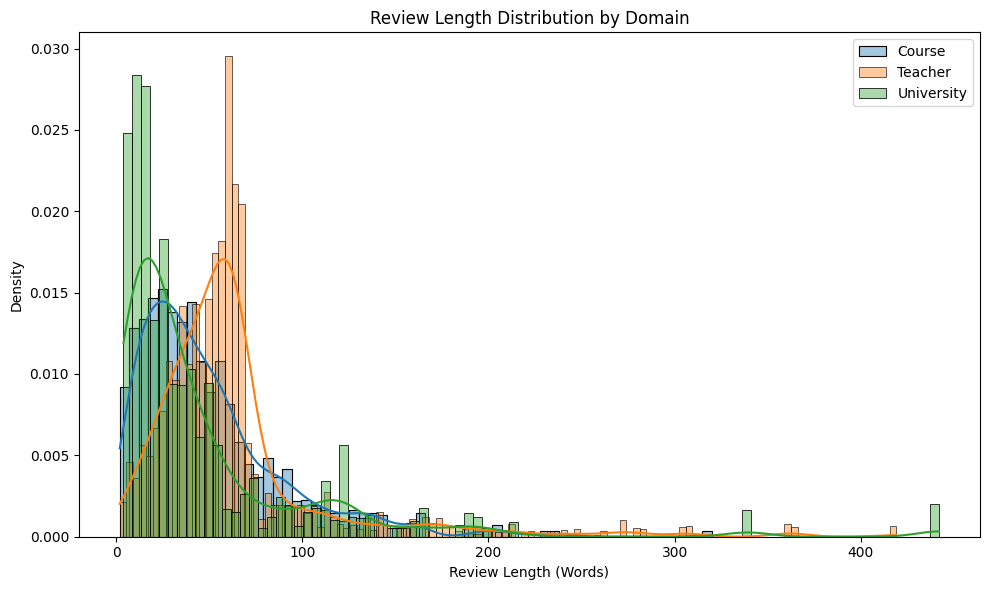

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(
    course_df["review_length"],
    label="Course",
    kde=True,
    stat="density",
    alpha=0.4
)

sns.histplot(
    teacher_df["review_length"],
    label="Teacher",
    kde=True,
    stat="density",
    alpha=0.4
)

sns.histplot(
    university_df["review_length"],
    label="University",
    kde=True,
    stat="density",
    alpha=0.4
)

plt.title(
    "Review Length Distribution by Domain"
)

plt.xlabel("Review Length (Words)")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/review_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

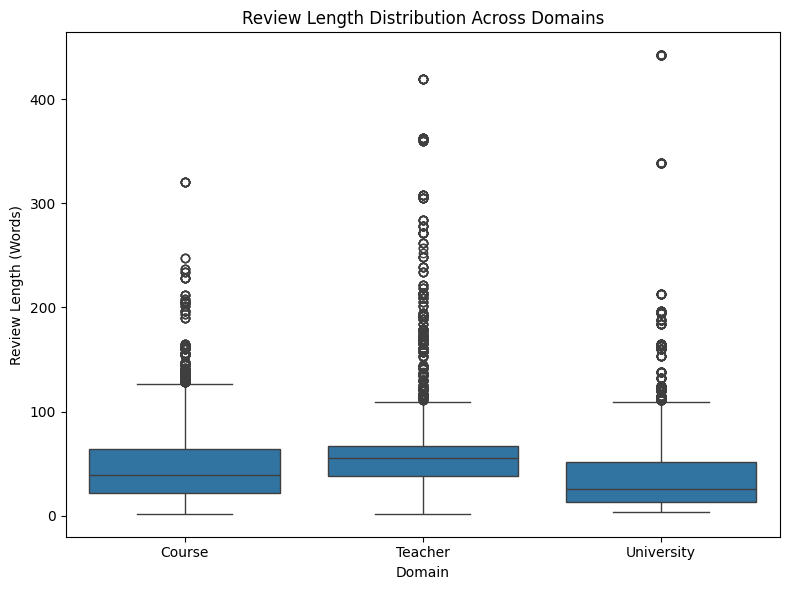

In [11]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=pd.concat([
        course_df[["review_length"]].assign(domain="Course"),
        teacher_df[["review_length"]].assign(domain="Teacher"),
        university_df[["review_length"]].assign(domain="University")
    ]),
    x="domain",
    y="review_length"
)

plt.title(
    "Review Length Distribution Across Domains"
)

plt.xlabel("Domain")
plt.ylabel("Review Length (Words)")

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/review_length_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
course_df["aspect_length"] = (
    course_df["aspect"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

teacher_df["aspect_length"] = (
    teacher_df["aspect"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

university_df["aspect_length"] = (
    university_df["aspect"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("\nCourse Aspect Length")
print(course_df["aspect_length"].describe())

print("\nTeacher Aspect Length")
print(teacher_df["aspect_length"].describe())

print("\nUniversity Aspect Length")
print(university_df["aspect_length"].describe())


Course Aspect Length
count    4218.000000
mean        1.645567
std         0.888245
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: aspect_length, dtype: float64

Teacher Aspect Length
count    4218.000000
mean        1.626363
std         0.800632
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: aspect_length, dtype: float64

University Aspect Length
count    4218.000000
mean        1.650782
std         0.896943
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: aspect_length, dtype: float64


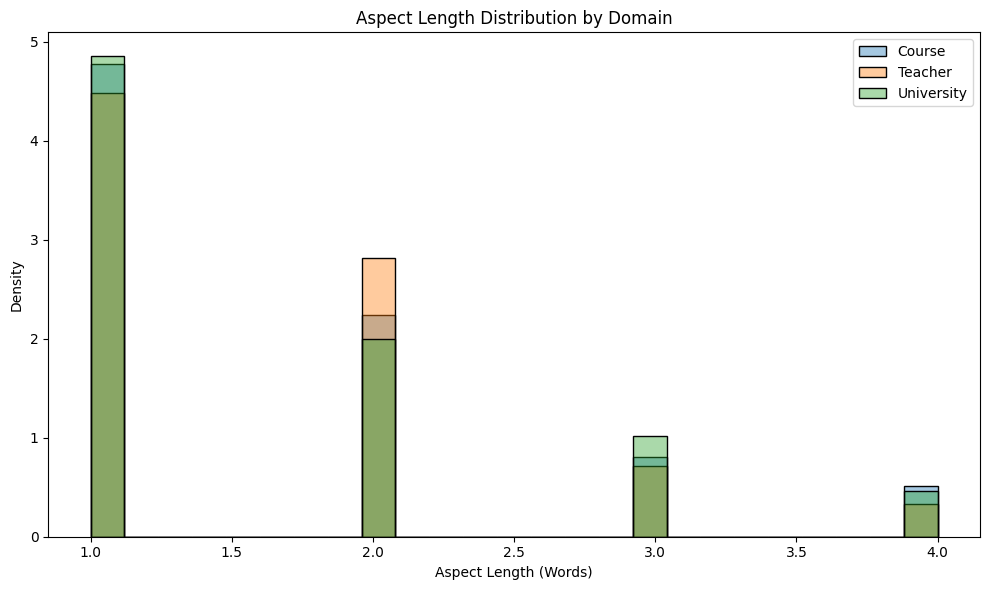

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    course_df["aspect_length"],
    label="Course",
    stat="density",
    alpha=0.4
)

sns.histplot(
    teacher_df["aspect_length"],
    label="Teacher",
    stat="density",
    alpha=0.4
)

sns.histplot(
    university_df["aspect_length"],
    label="University",
    stat="density",
    alpha=0.4
)

plt.title(
    "Aspect Length Distribution by Domain"
)

plt.xlabel("Aspect Length (Words)")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/aspect_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

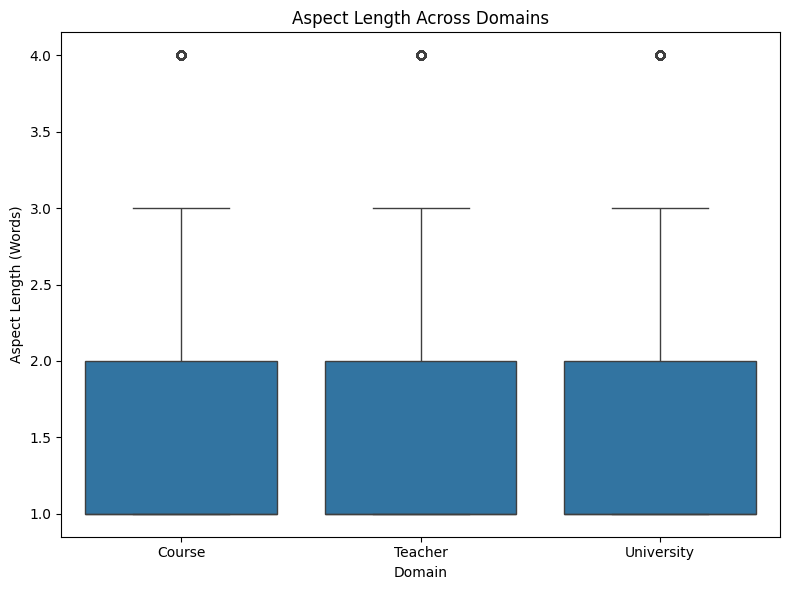

In [14]:
aspect_plot_df = pd.concat([
    course_df[["aspect_length"]].assign(domain="Course"),
    teacher_df[["aspect_length"]].assign(domain="Teacher"),
    university_df[["aspect_length"]].assign(domain="University")
])

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=aspect_plot_df,
    x="domain",
    y="aspect_length"
)

plt.title(
    "Aspect Length Across Domains"
)

plt.xlabel("Domain")
plt.ylabel("Aspect Length (Words)")

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/aspect_length_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

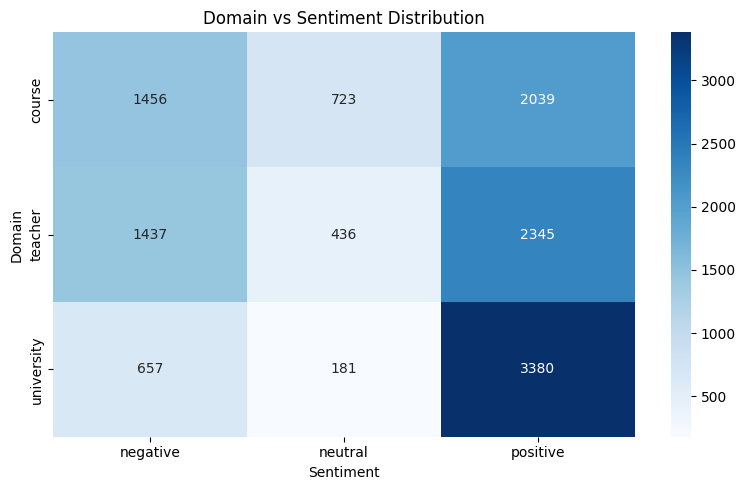

sentiment,negative,neutral,positive
domain,,,
course,1456,723,2039
teacher,1437,436,2345
university,657,181,3380


In [15]:
sentiment_heatmap = pd.crosstab(
    multidomain_df["domain"],
    multidomain_df["sentiment"]
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    sentiment_heatmap,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Domain vs Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Domain")

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/domain_sentiment_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

sentiment_heatmap

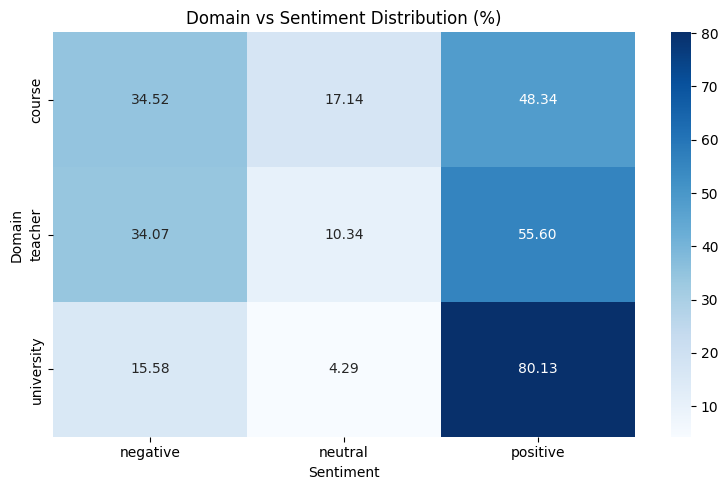

sentiment,negative,neutral,positive
domain,,,
course,34.518729,17.140825,48.340446
teacher,34.068279,10.336652,55.595069
university,15.576102,4.291133,80.132764


In [16]:
sentiment_heatmap_pct = pd.crosstab(
    multidomain_df["domain"],
    multidomain_df["sentiment"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 5))

sns.heatmap(
    sentiment_heatmap_pct,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title(
    "Domain vs Sentiment Distribution (%)"
)

plt.xlabel("Sentiment")
plt.ylabel("Domain")

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/domain_sentiment_heatmap_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

sentiment_heatmap_pct

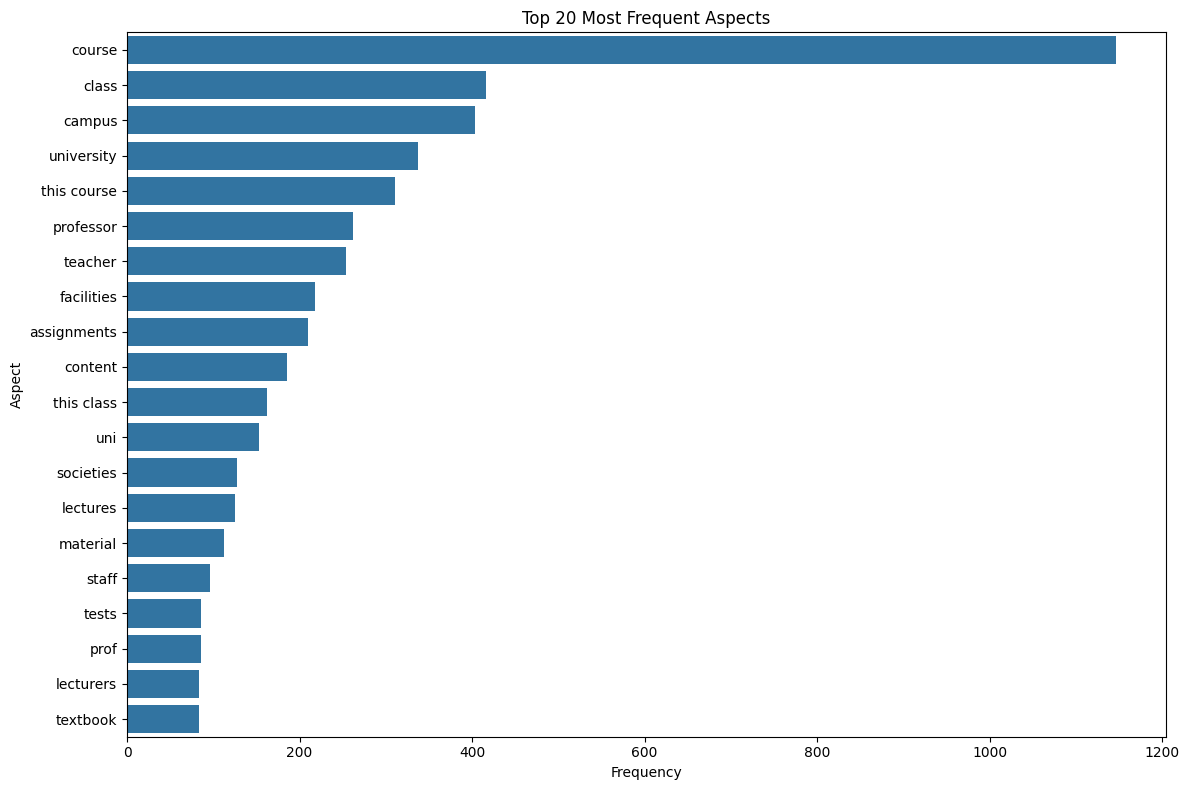

aspect
course         1147
class           416
campus          403
university      337
this course     311
professor       262
teacher         254
facilities      218
assignments     210
content         185
this class      162
uni             153
societies       127
lectures        125
material        112
staff            96
tests            86
prof             86
lecturers        84
textbook         84
Name: count, dtype: int64


In [17]:
top_aspects = (
    multidomain_df["aspect"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_aspects.values,
    y=top_aspects.index
)

plt.title(
    "Top 20 Most Frequent Aspects"
)

plt.xlabel("Frequency")
plt.ylabel("Aspect")

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/top_20_aspects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(top_aspects)

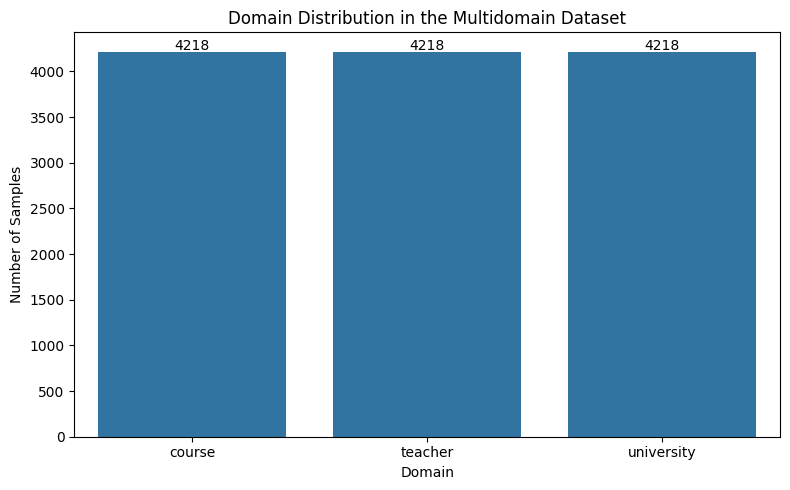

domain
course        4218
teacher       4218
university    4218
Name: count, dtype: int64


In [18]:
domain_counts = (
    multidomain_df["domain"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=domain_counts.index,
    y=domain_counts.values
)

plt.title(
    "Domain Distribution in the Multidomain Dataset"
)

plt.xlabel("Domain")
plt.ylabel("Number of Samples")

for i, count in enumerate(domain_counts.values):
    plt.text(
        i,
        count + 20,
        str(count),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/domain_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(domain_counts)

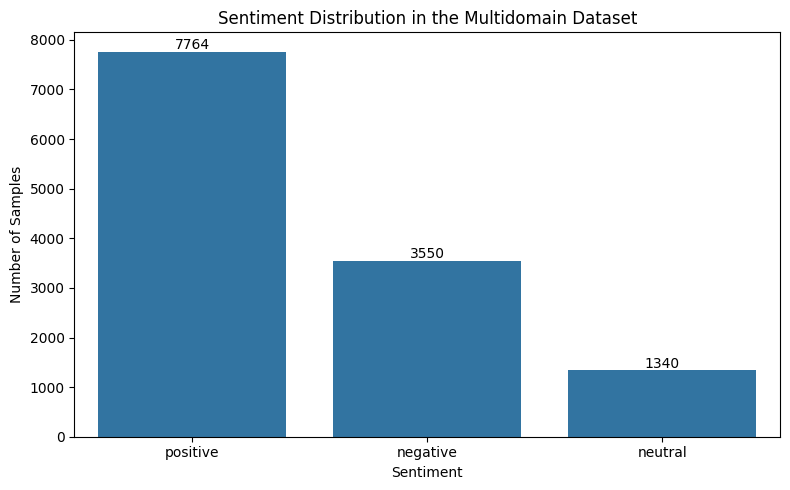

sentiment
positive    7764
negative    3550
neutral     1340
Name: count, dtype: int64

Percentages:
sentiment
positive    61.36
negative    28.05
neutral     10.59
Name: proportion, dtype: float64


In [19]:
sentiment_counts = (
    multidomain_df["sentiment"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title(
    "Sentiment Distribution in the Multidomain Dataset"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")

for i, count in enumerate(sentiment_counts.values):
    plt.text(
        i,
        count + 50,
        str(count),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(sentiment_counts)

print("\nPercentages:")
print(
    (
        multidomain_df["sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)
)

In [20]:
multidomain_df["review_length"] = (
    multidomain_df["review"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

multidomain_df["aspect_length"] = (
    multidomain_df["aspect"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print(multidomain_df.columns)

Index(['review', 'aspect', 'sentiment', 'domain', 'row_id', 'label',
       'review_length', 'aspect_length'],
      dtype='object')


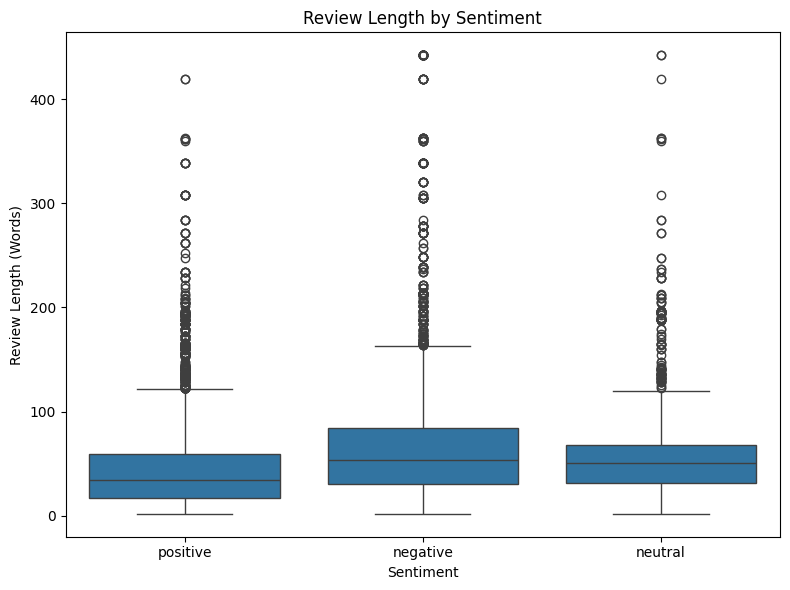

            count       mean        std  min   25%   50%   75%    max
sentiment                                                            
negative   3550.0  72.365915  71.943287  2.0  31.0  54.0  84.0  442.0
neutral    1340.0  60.824627  49.917660  2.0  32.0  51.0  68.0  442.0
positive   7764.0  44.674137  40.540372  2.0  17.0  34.0  59.0  419.0


In [21]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=multidomain_df,
    x="sentiment",
    y="review_length"
)

plt.title(
    "Review Length by Sentiment"
)

plt.xlabel("Sentiment")
plt.ylabel("Review Length (Words)")

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/review_length_by_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    multidomain_df.groupby("sentiment")["review_length"]
    .describe()
)

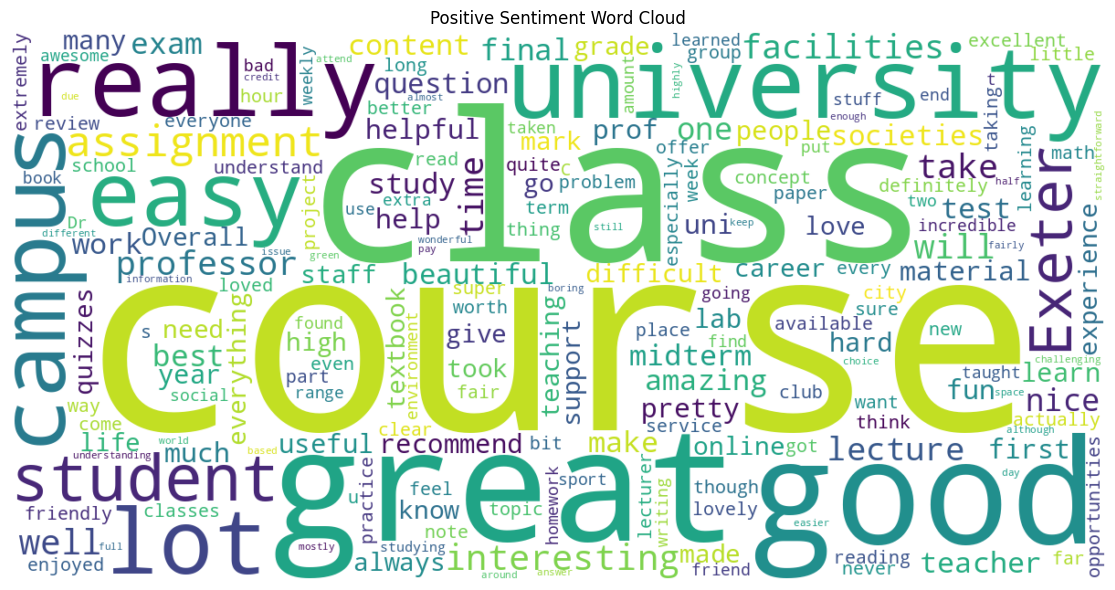

In [22]:
positive_text = " ".join(
    multidomain_df[
        multidomain_df["sentiment"] == "positive"
    ]["review"].astype(str)
)

positive_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    collocations=False
).generate(positive_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    positive_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Positive Sentiment Word Cloud"
)

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/positive_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

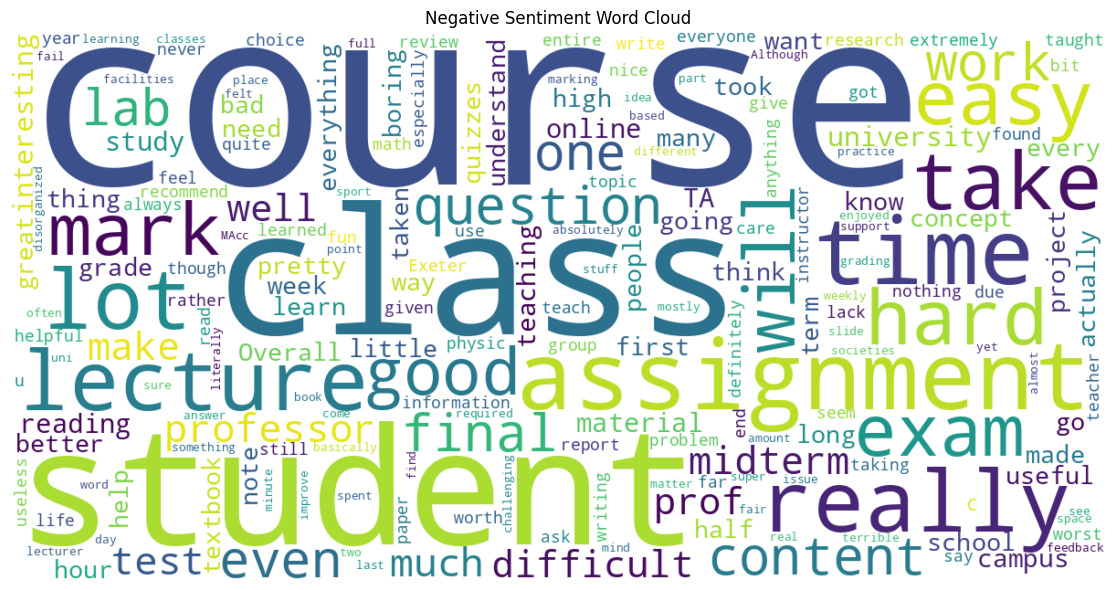

In [23]:
negative_text = " ".join(
    multidomain_df[
        multidomain_df["sentiment"] == "negative"
    ]["review"].astype(str)
)

negative_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    collocations=False
).generate(negative_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    negative_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Negative Sentiment Word Cloud"
)

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/negative_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

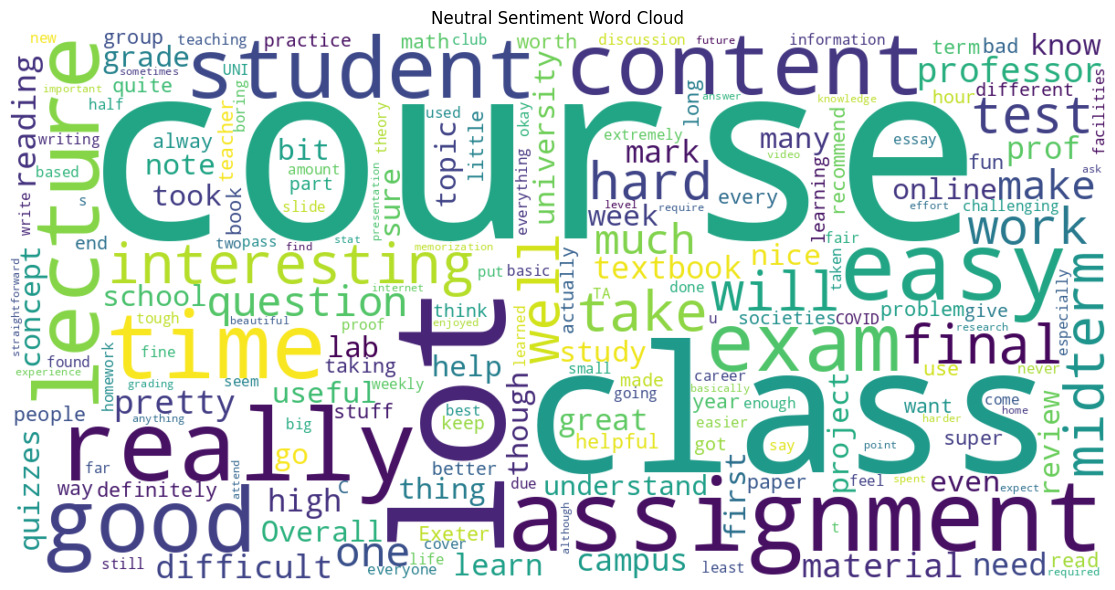

In [24]:
neutral_text = " ".join(
    multidomain_df[
        multidomain_df["sentiment"] == "neutral"
    ]["review"].astype(str)
)

neutral_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    collocations=False
).generate(neutral_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    neutral_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Neutral Sentiment Word Cloud"
)

plt.tight_layout()

plt.savefig(
    f"{EDA_OUTPUT}/neutral_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Exploratory Data Analysis (EDA) Findings

## Domain Distribution

The multidomain dataset was successfully balanced at the domain level. Each domain contributes an equal number of samples to the training corpus, ensuring that no domain disproportionately influences model learning.

| Domain     |    Samples |
| ---------- | ---------: |
| Course     |      4,218 |
| Teacher    |      4,218 |
| University |      4,218 |
| **Total**  | **12,654** |

This balanced domain distribution supports fair multidomain learning and reduces the risk of domain-specific bias during training.

---

## Sentiment Distribution

Although the domains were balanced, the sentiment classes remained naturally imbalanced.

| Sentiment | Count | Percentage |
| --------- | ----: | ---------: |
| Positive  | 7,764 |     61.36% |
| Negative  | 3,550 |     28.05% |
| Neutral   | 1,340 |     10.59% |

The dataset is strongly dominated by positive sentiment, while neutral sentiment is substantially underrepresented. This imbalance increases the difficulty of sentiment classification and justifies the use of weighted evaluation metrics such as weighted F1-score.

---

## Domain-Specific Sentiment Analysis

The sentiment distribution varies considerably across domains.

| Domain     | Negative (%) | Neutral (%) | Positive (%) |
| ---------- | -----------: | ----------: | -----------: |
| Course     |        34.52 |       17.14 |        48.34 |
| Teacher    |        34.07 |       10.34 |        55.60 |
| University |        15.58 |        4.29 |        80.13 |

The University domain exhibits a strong positive bias, with more than 80% of instances expressing positive sentiment. This characteristic helps explain why the University domain has consistently achieved higher performance across previous experiments.

---

## Review Length Analysis

### Average Review Length by Domain

| Domain     | Mean Review Length (Words) |
| ---------- | -------------------------: |
| Course     |                      50.17 |
| Teacher    |                      64.56 |
| University |                      47.73 |

Teacher reviews are noticeably longer than reviews in the other domains, providing more contextual information for sentiment prediction.

### Average Review Length by Sentiment

| Sentiment | Mean Review Length (Words) |
| --------- | -------------------------: |
| Positive  |                      44.67 |
| Neutral   |                      60.82 |
| Negative  |                      72.37 |

Negative reviews are substantially longer than positive reviews. This suggests that students tend to provide more detailed explanations when expressing dissatisfaction, potentially making negative sentiment easier to identify.

The maximum observed review length was 442 words, while the majority of reviews were considerably shorter. Therefore, a maximum sequence length of 256 tokens remains an appropriate choice for model training.

---

## Aspect Length Analysis

Aspect terms were generally concise across all domains.

| Domain     | Mean Aspect Length |
| ---------- | -----------------: |
| Course     |         1.65 words |
| Teacher    |         1.63 words |
| University |         1.65 words |

Additional observations include:

* Median aspect length: 1 word
* Maximum aspect length: 4 words

These results indicate that aspect terms are typically short and compact, meaning that sequence length requirements are driven primarily by review text rather than aspect length.

---

## Aspect Frequency Analysis

The most frequently occurring aspects within the multidomain dataset were:

1. Course
2. Class
3. Campus
4. University
5. This Course
6. Professor
7. Teacher
8. Facilities
9. Assignments
10. Content

The aspect distribution is highly skewed, with a small number of frequent aspects accounting for a large proportion of the dataset. Consequently, models must learn to generalize across both common and infrequent aspect terms, increasing the complexity of the ABSA task.

---

## Word Cloud Analysis

Word cloud visualizations revealed clear differences in vocabulary usage across sentiment classes.

### Positive Sentiment

Positive reviews frequently contained terms such as:

* Great
* Good
* Class
* Course
* Easy
* Campus
* Helpful
* Interesting

These words reflect satisfaction with teaching quality, course content, and university facilities.

### Negative Sentiment

Negative reviews commonly included terms such as:

* Difficult
* Assignment
* Professor
* Exam
* Question
* Lecture
* Mark

These terms suggest that assessments, workload, and instructional quality are major sources of dissatisfaction.

### Neutral Sentiment

Neutral reviews were characterized by words such as:

* Assignment
* Lecture
* Class
* Course
* Exam
* Student

These reviews generally focused on describing course characteristics without expressing strong positive or negative opinions.

---

## Summary

The exploratory analysis revealed several important characteristics of the multidomain ABSA dataset. While domain-level balancing was successfully achieved, significant sentiment imbalance remains, with positive sentiment representing over 61% of all instances. The University domain exhibits a particularly strong positive bias, whereas Course and Teacher domains contain more balanced sentiment distributions. Negative reviews tend to be considerably longer than positive reviews, providing richer contextual information for sentiment classification. Aspect terms are generally short, averaging approximately 1.6 words across domains, while review lengths remain well within the selected maximum sequence length of 256 tokens. These findings provide important context for interpreting model performance during subsequent LoRA hyperparameter tuning experiments.


In [25]:
from sklearn.model_selection import train_test_split

SEED = 42

def split_domain(df):

    train_df, test_df = train_test_split(

        df,

        test_size=0.2,

        stratify=df["label"],

        random_state=SEED
    )

    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    return train_df, test_df

course_train, course_test = split_domain(course_df)

teacher_train, teacher_test = split_domain(teacher_df)

university_train, university_test = split_domain(university_df)

print("Splits created successfully.\n")

print("Course")
print("Train:", len(course_train))
print("Test :", len(course_test))

print("\nTeacher")
print("Train:", len(teacher_train))
print("Test :", len(teacher_test))

print("\nUniversity")
print("Train:", len(university_train))
print("Test :", len(university_test))

Splits created successfully.

Course
Train: 3374
Test : 844

Teacher
Train: 3374
Test : 844

University
Train: 3374
Test : 844


In [26]:
for name, df in {

    "Course Train": course_train,
    "Course Test": course_test,

    "Teacher Train": teacher_train,
    "Teacher Test": teacher_test,

    "University Train": university_train,
    "University Test": university_test

}.items():

    print("\n" + "=" * 60)
    print(name)

    print(
        (
            df["label"]
            .value_counts(normalize=True)
            * 100
        ).round(2)
    )


Course Train
label
2    48.34
0    34.53
1    17.13
Name: proportion, dtype: float64

Course Test
label
2    48.34
0    34.48
1    17.18
Name: proportion, dtype: float64

Teacher Train
label
2    55.60
0    34.05
1    10.34
Name: proportion, dtype: float64

Teacher Test
label
2    55.57
0    34.12
1    10.31
Name: proportion, dtype: float64

University Train
label
2    80.14
0    15.56
1     4.30
Name: proportion, dtype: float64

University Test
label
2    80.09
0    15.64
1     4.27
Name: proportion, dtype: float64


In [27]:
course_test.to_csv(
    f"{SHARED_TEST_PATH}/course_test.csv",
    index=False
)

teacher_test.to_csv(
    f"{SHARED_TEST_PATH}/teacher_test.csv",
    index=False
)

university_test.to_csv(
    f"{SHARED_TEST_PATH}/university_test.csv",
    index=False
)

print("Shared test sets saved successfully.")

Shared test sets saved successfully.


In [28]:
multidomain_train_df = pd.concat(
    [
        course_train,
        teacher_train,
        university_train
    ],
    ignore_index=True
)

print(
    "Multidomain Train Shape:",
    multidomain_train_df.shape
)

print("\nDomain Distribution:")
print(
    multidomain_train_df["domain"]
    .value_counts()
)

print("\nLabel Distribution:")
print(
    multidomain_train_df["label"]
    .value_counts()
)

Multidomain Train Shape: (10122, 8)

Domain Distribution:
domain
course        3374
teacher       3374
university    3374
Name: count, dtype: int64

Label Distribution:
label
2    6211
0    2839
1    1072
Name: count, dtype: int64


In [29]:
classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=multidomain_train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print("Class Weights:")
print(class_weights)

Class Weights:
tensor([1.1884, 3.1474, 0.5432])


In [30]:
def create_prompt(review, aspect, label=None):

    prompt = f"""You are an expert aspect-based sentiment analysis classifier.

Determine the sentiment expressed towards the given aspect.

Review:
{review}

Aspect:
{aspect}

Possible sentiments:
positive
negative
neutral"""

    # TRAINING LABEL

    if label is not None:

        prompt += f"\n\nSentiment:\n{id2label[label]}"

    return prompt.strip()


example_prompt = create_prompt(
    review=course_df.iloc[0]["review"],
    aspect=course_df.iloc[0]["aspect"],
    label=course_df.iloc[0]["label"]
)

print(example_prompt)

You are an expert aspect-based sentiment analysis classifier.

Determine the sentiment expressed towards the given aspect.

Review:
This course was amazing. For the first time, there's no worrying about your lab partner: it's just you and the chemicals. When I took this course, it was just 4 long experiments and you organize your time accordingly throughout the semester: for students taking it in Fall 2016, you now have 7+ experiments, so I'm not sure how much the formatting's changed. It's a lot of work, but it's incredibly rewarding. I loved it.

Aspect:
course

Possible sentiments:
positive
negative
neutral

Sentiment:
positive


In [31]:
train_prompts = []

for _, row in multidomain_train_df.iterrows():

    prompt = create_prompt(
        review=row["review"],
        aspect=row["aspect"],
        label=row["label"]
    )

    train_prompts.append({

        "text": prompt,

        "row_id": row["row_id"],

        "domain": row["domain"],

        "label": row["label"]

    })

print("Total Training Prompts:")
print(len(train_prompts))

print("\nSample Training Prompt:\n")

print(
    train_prompts[0]["text"][:1000]
)

print("\nMetadata Example:")

print(
    {
        "row_id": train_prompts[0]["row_id"],
        "domain": train_prompts[0]["domain"],
        "label": train_prompts[0]["label"]
    }
)

Total Training Prompts:
10122

Sample Training Prompt:

You are an expert aspect-based sentiment analysis classifier.

Determine the sentiment expressed towards the given aspect.

Review:
I was pleasantly surprised by this course. It seems to have been changed significantly over the past few years, and is now a better fit for iterative software development methodologies. Assignments are based on collecting and analyzing requirements and specifications for your capstone project, which can be useful. The course covers a width breadth of topics, though the final exam is almost entirely application-based.

Aspect:
the final exam

Possible sentiments:
positive
negative
neutral

Sentiment:
neutral

Metadata Example:
{'row_id': 'course_1306', 'domain': 'course', 'label': 1}


In [32]:
train_dataset = Dataset.from_pandas(
    pd.DataFrame(train_prompts)
)

print(train_dataset)

print("\nSample Dataset Entry:\n")
print(train_dataset[0])

Dataset({
    features: ['text', 'row_id', 'domain', 'label'],
    num_rows: 10122
})

Sample Dataset Entry:

{'text': 'You are an expert aspect-based sentiment analysis classifier.\n\nDetermine the sentiment expressed towards the given aspect.\n\nReview:\nI was pleasantly surprised by this course. It seems to have been changed significantly over the past few years, and is now a better fit for iterative software development methodologies. Assignments are based on collecting and analyzing requirements and specifications for your capstone project, which can be useful. The course covers a width breadth of topics, though the final exam is almost entirely application-based.\n\nAspect:\nthe final exam\n\nPossible sentiments:\npositive\nnegative\nneutral\n\nSentiment:\nneutral', 'row_id': 'course_1306', 'domain': 'course', 'label': 1}


In [33]:
test_prompts = {}

for domain_name, test_df in {

    "course": course_test,

    "teacher": teacher_test,

    "university": university_test

}.items():

    prompts = []

    for _, row in test_df.iterrows():

        prompt = create_prompt(
            review=row["review"],
            aspect=row["aspect"]
        )

        prompts.append({

            "text": prompt,

            "row_id": row["row_id"],

            "domain": domain_name,

            "label": row["label"]

        })

    test_prompts[domain_name] = prompts

print("Course Test Prompts:",
      len(test_prompts["course"]))

print("Teacher Test Prompts:",
      len(test_prompts["teacher"]))

print("University Test Prompts:",
      len(test_prompts["university"]))

Course Test Prompts: 844
Teacher Test Prompts: 844
University Test Prompts: 844


In [35]:
MAX_LENGTH = 256

print(
    "Maximum Sequence Length:",
    MAX_LENGTH
)

Maximum Sequence Length: 256


In [36]:
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print("Model:", MODEL_NAME)
print("Pad Token:", tokenizer.pad_token)
print("EOS Token:", tokenizer.eos_token)

Model: meta-llama/Llama-3.2-3B-Instruct
Pad Token: <|eot_id|>
EOS Token: <|eot_id|>


In [37]:
def tokenize_function(example):

    tokens = tokenizer(

        example["text"],

        truncation=True,

        padding="max_length",

        max_length=MAX_LENGTH
    )

    tokens["labels"] = (
        tokens["input_ids"].copy()
    )

    return tokens


tokenized_train_dataset = train_dataset.map(

    tokenize_function,

    batched=False,

    remove_columns=[
        "text",
        "row_id",
        "domain",
        "label"
    ]
)

print("\nDataset tokenized successfully.")

print(tokenized_train_dataset)

Map: 100%|██████████| 10122/10122 [00:06<00:00, 1525.02 examples/s]


Dataset tokenized successfully.
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 10122
})


In [38]:
split_dataset = tokenized_train_dataset.train_test_split(

    test_size=0.1,

    seed=42
)

train_dataset_final = split_dataset["train"]

val_dataset_final = split_dataset["test"]

print("Training Samples:")
print(len(train_dataset_final))

print("\nValidation Samples:")
print(len(val_dataset_final))

Training Samples:
9109

Validation Samples:
1013


In [39]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("Data collator initialized.")

Data collator initialized.


In [40]:
bnb_config = BitsAndBytesConfig(

    load_in_4bit=True,

    bnb_4bit_quant_type="nf4",

    bnb_4bit_compute_dtype=torch.bfloat16,

    bnb_4bit_use_double_quant=True
)

print("BitsAndBytes configuration created.")

BitsAndBytes configuration created.


In [41]:
model = AutoModelForCausalLM.from_pretrained(

    MODEL_NAME,

    quantization_config=bnb_config,

    device_map="auto",

    torch_dtype=torch.bfloat16,

    low_cpu_mem_usage=True
)

print("Base model loaded.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 254/254 [00:01<00:00, 135.68it/s]


Base model loaded.


In [42]:
model = prepare_model_for_kbit_training(
    model
)

print("Model prepared for k-bit training.")

Model prepared for k-bit training.


In [43]:
lora_config = LoraConfig(

    r=16,

    lora_alpha=32,

    lora_dropout=0.05,

    bias="none",

    task_type="CAUSAL_LM",

    target_modules=[

        "q_proj",

        "k_proj",

        "v_proj",

        "o_proj",

        "gate_proj",

        "up_proj",

        "down_proj"
    ]
)

print("LoRA configuration created.")

LoRA configuration created.


In [44]:
model = get_peft_model(
    model,
    lora_config
)

model.gradient_checkpointing_enable()

model.config.use_cache = False

model.print_trainable_parameters()

print("\nQLoRA model loaded successfully.")

trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511

QLoRA model loaded successfully.


In [45]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir=f"{LR_5E5_OUTPUT}/training_output",

    num_train_epochs=5,

    learning_rate=5e-5,

    per_device_train_batch_size=1,

    gradient_accumulation_steps=16,

    logging_steps=20,

    save_strategy="no",

    eval_strategy="no",

    bf16=True,

    fp16=False,

    gradient_checkpointing=True,

    optim="paged_adamw_8bit",

    remove_unused_columns=False,

    report_to="none"
)

print("LR=5e-5 Training Arguments Configured.")

LR=5e-5 Training Arguments Configured.


In [46]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset_final,

    data_collator=data_collator
)

print("Trainer initialized.")

Trainer initialized.


In [47]:
trainer.train()

Step,Training Loss
20,2.551646
40,2.056170
60,1.987122
80,1.882919
100,1.810582
120,1.842434
140,1.834494
160,1.822479
180,1.740909
200,1.847851


TrainOutput(global_step=2850, training_loss=1.1030810120231227, metrics={'train_runtime': 29762.1453, 'train_samples_per_second': 1.53, 'train_steps_per_second': 0.096, 'total_flos': 1.9889237689368576e+17, 'train_loss': 1.1030810120231227, 'epoch': 5.0})

In [48]:
model.save_pretrained(
    f"{LR_5E5_OUTPUT}/final_model"
)

tokenizer.save_pretrained(
    f"{LR_5E5_OUTPUT}/final_model"
)

print("LR=5e-5 model saved successfully.")

LR=5e-5 model saved successfully.


In [49]:
import gc

gc.collect()

torch.cuda.empty_cache()

print("GPU cache cleared.")

GPU cache cleared.


In [50]:
import os

print(
    os.listdir(
        f"{LR_5E5_OUTPUT}/final_model"
    )
)

['chat_template.jinja', 'README.md', 'tokenizer_config.json', 'adapter_model.safetensors', 'tokenizer.json', 'adapter_config.json']


In [51]:
# LOAD SHARED TEST SETS

course_test = pd.read_csv(
    f"{SHARED_TEST_PATH}/course_test.csv"
)

teacher_test = pd.read_csv(
    f"{SHARED_TEST_PATH}/teacher_test.csv"
)

university_test = pd.read_csv(
    f"{SHARED_TEST_PATH}/university_test.csv"
)

print("Shared test sets loaded successfully.\n")

print("Course Test Shape:")
print(course_test.shape)

print("\nTeacher Test Shape:")
print(teacher_test.shape)

print("\nUniversity Test Shape:")
print(university_test.shape)

Shared test sets loaded successfully.

Course Test Shape:
(844, 8)

Teacher Test Shape:
(844, 8)

University Test Shape:
(844, 8)


In [52]:
# =====================================================
# LOAD SAVED LORA MODEL
# =====================================================

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

from peft import PeftModel

MODEL_PATH = f"{LR_5E5_OUTPUT}/final_model"

bnb_config = BitsAndBytesConfig(

    load_in_4bit=True,

    bnb_4bit_quant_type="nf4",

    bnb_4bit_compute_dtype=torch.bfloat16,

    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

base_model = AutoModelForCausalLM.from_pretrained(

    MODEL_NAME,

    quantization_config=bnb_config,

    device_map="auto",

    torch_dtype=torch.bfloat16
)

model = PeftModel.from_pretrained(

    base_model,

    MODEL_PATH
)

model.eval()

print(
    "LR=5e-5 LoRA model loaded successfully."
)

Loading weights: 100%|██████████| 254/254 [00:02<00:00, 121.09it/s]


LR=5e-5 LoRA model loaded successfully.


In [53]:
# INFERENCE FUNCTION


def generate_prediction(review, aspect):

    prompt = f"""You are an expert aspect-based sentiment analysis classifier.

Determine the sentiment expressed towards the given aspect.

Review:
{review}

Aspect:
{aspect}

Possible sentiments:
positive
negative
neutral

Sentiment:"""

    inputs = tokenizer(

        prompt,

        return_tensors="pt",

        truncation=True,

        max_length=256

    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(

            **inputs,

            max_new_tokens=5,

            do_sample=False,

            temperature=None,

            pad_token_id=tokenizer.eos_token_id
        )

    prediction = tokenizer.decode(

    outputs[0],

    skip_special_tokens=True,

    clean_up_tokenization_spaces=False
)
    prediction = prediction.split(
        "Sentiment:"
    )[-1].strip().lower()

    if "positive" in prediction:

        return "positive"

    elif "negative" in prediction:

        return "negative"

    elif "neutral" in prediction:

        return "neutral"

    else:

        return "neutral"


print("LoRA inference function created.")

LoRA inference function created.


In [54]:
# TEST SINGLE PREDICTION

sample_prediction = generate_prediction(
    review=course_test.iloc[0]["review"],
    aspect=course_test.iloc[0]["aspect"]
)

print("Review:")
print(course_test.iloc[0]["review"])

print("\nAspect:")
print(course_test.iloc[0]["aspect"])

print("\nTrue Sentiment:")
print(course_test.iloc[0]["sentiment"])

print("\nPredicted Sentiment:")
print(sample_prediction)

Review:
The programming language( Scheme/ Dr. Racket) wasn't a very good program to use but the concepts behind it are the same I guess...

Aspect:
programming language

True Sentiment:
negative

Predicted Sentiment:
negative


In [55]:
# COURSE PREDICTIONS


course_predictions = []

for idx, row in course_test.iterrows():

    pred = generate_prediction(

        review=row["review"],

        aspect=row["aspect"]

    )

    course_predictions.append({

        "row_id": row["row_id"],

        "domain": "course",

        "review": row["review"],

        "aspect": row["aspect"],

        "true_label": row["sentiment"],

        "predicted_label": pred

    })

    if (idx + 1) % 50 == 0:

        print(
            f"Processed {idx + 1}/{len(course_test)}"
        )

course_predictions_df = pd.DataFrame(
    course_predictions
)

print("\nCourse predictions completed.")

print("\nPrediction Distribution:")
print(
    course_predictions_df["predicted_label"]
    .value_counts()
)

print("\nFirst 5 Predictions:")
print(
    course_predictions_df.head()
)


course_predictions_df.to_csv(

    f"{LR_5E5_OUTPUT}/predictions/course_predictions.csv",

    index=False

)

print(
    "\nCourse predictions saved successfully."
)

print(
    f"Total Predictions: {len(course_predictions_df)}"
)

Processed 50/844
Processed 100/844
Processed 150/844
Processed 200/844
Processed 250/844
Processed 300/844
Processed 350/844
Processed 400/844
Processed 450/844
Processed 500/844
Processed 550/844
Processed 600/844
Processed 650/844
Processed 700/844
Processed 750/844
Processed 800/844

Course predictions completed.

Prediction Distribution:
predicted_label
positive    403
negative    249
neutral     192
Name: count, dtype: int64

First 5 Predictions:
        row_id  domain                                             review  \
0   course_188  course  The programming language( Scheme/ Dr. Racket) ...   
1  course_3409  course  This class is literally just epsilon and delta...   
2   course_254  course  Overall content heavy and quite a tricky cours...   
3  course_1797  course  Professor Sneed's class was a semi tough one. ...   
4  course_3891  course  Despite many ppl complaining about the Mobius ...   

                  aspect true_label predicted_label  
0   programming language   

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)

course_accuracy = accuracy_score(
    course_predictions_df["true_label"],
    course_predictions_df["predicted_label"]
)

course_macro_f1 = f1_score(
    course_predictions_df["true_label"],
    course_predictions_df["predicted_label"],
    average="macro"
)

course_weighted_f1 = f1_score(
    course_predictions_df["true_label"],
    course_predictions_df["predicted_label"],
    average="weighted"
)

print("COURSE RESULTS")
print("=" * 50)

print(f"Accuracy: {course_accuracy:.4f}")
print(f"Macro F1: {course_macro_f1:.4f}")
print(f"Weighted F1: {course_weighted_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        course_predictions_df["true_label"],
        course_predictions_df["predicted_label"]
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        course_predictions_df["true_label"],
        course_predictions_df["predicted_label"]
    )
)

COURSE RESULTS
Accuracy: 0.7855
Macro F1: 0.7388
Weighted F1: 0.7946

Classification Report:

              precision    recall  f1-score   support

    negative       0.91      0.78      0.84       291
     neutral       0.45      0.60      0.52       145
    positive       0.87      0.86      0.86       408

    accuracy                           0.79       844
   macro avg       0.74      0.74      0.74       844
weighted avg       0.81      0.79      0.79       844


Confusion Matrix:

[[226  52  13]
 [ 18  87  40]
 [  5  53 350]]


In [61]:
# =====================================================
# TEACHER PREDICTIONS
# =====================================================

teacher_predictions = []

for idx, row in teacher_test.iterrows():

    pred = generate_prediction(

        review=row["review"],

        aspect=row["aspect"]

    )

    teacher_predictions.append({

        "row_id": row["row_id"],

        "domain": "teacher",

        "review": row["review"],

        "aspect": row["aspect"],

        "true_label": row["sentiment"],

        "predicted_label": pred

    })

    if (idx + 1) % 50 == 0:

        print(
            f"Processed {idx + 1}/{len(teacher_test)}"
        )

teacher_predictions_df = pd.DataFrame(
    teacher_predictions
)

print("\nTeacher predictions completed.")

print("\nPrediction Distribution:")
print(
    teacher_predictions_df["predicted_label"]
    .value_counts()
)

print("\nFirst 5 Predictions:")
print(
    teacher_predictions_df.head()
)

# =====================================================
# SAVE PREDICTIONS
# =====================================================

teacher_predictions_df.to_csv(

    f"{LR_5E5_OUTPUT}/predictions/teacher_predictions.csv",

    index=False

)

print(
    "\nTeacher predictions saved successfully."
)

print(
    f"Total Predictions: {len(teacher_predictions_df)}"
)

Processed 50/844
Processed 100/844
Processed 150/844
Processed 200/844
Processed 250/844
Processed 300/844
Processed 350/844
Processed 400/844
Processed 450/844
Processed 500/844
Processed 550/844
Processed 600/844
Processed 650/844
Processed 700/844
Processed 750/844
Processed 800/844

Teacher predictions completed.

Prediction Distribution:
predicted_label
positive    460
negative    248
neutral     136
Name: count, dtype: int64

First 5 Predictions:
         row_id   domain                                             review  \
0  teacher_3717  teacher  This class was harder than I expected, especia...   
1   teacher_671  teacher  Good teacher, very helpful. He is very funny a...   
2  teacher_2314  teacher  Ms. Young is a great professor. I was computer...   
3  teacher_1051  teacher  TURN YOUR WORK IN ON TIME!!!! In only the seco...   
4  teacher_1118  teacher  Truly a sweet professor. Very understanding an...   

                   aspect true_label predicted_label  
0            

In [62]:
# =====================================================
# TEACHER EVALUATION
# =====================================================

teacher_accuracy = accuracy_score(
    teacher_predictions_df["true_label"],
    teacher_predictions_df["predicted_label"]
)

teacher_macro_f1 = f1_score(
    teacher_predictions_df["true_label"],
    teacher_predictions_df["predicted_label"],
    average="macro"
)

teacher_weighted_f1 = f1_score(
    teacher_predictions_df["true_label"],
    teacher_predictions_df["predicted_label"],
    average="weighted"
)

print("TEACHER RESULTS")
print("=" * 50)

print(f"Accuracy: {teacher_accuracy:.4f}")
print(f"Macro F1: {teacher_macro_f1:.4f}")
print(f"Weighted F1: {teacher_weighted_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        teacher_predictions_df["true_label"],
        teacher_predictions_df["predicted_label"]
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        teacher_predictions_df["true_label"],
        teacher_predictions_df["predicted_label"]
    )
)

TEACHER RESULTS
Accuracy: 0.8164
Macro F1: 0.7072
Weighted F1: 0.8300

Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.77      0.83       288
     neutral       0.31      0.48      0.38        87
    positive       0.92      0.90      0.91       469

    accuracy                           0.82       844
   macro avg       0.71      0.72      0.71       844
weighted avg       0.85      0.82      0.83       844


Confusion Matrix:

[[223  57   8]
 [ 17  42  28]
 [  8  37 424]]


In [59]:
# UNIVERSITY PREDICTIONS

university_predictions = []

for idx, row in university_test.iterrows():

    pred = generate_prediction(

        review=row["review"],

        aspect=row["aspect"]

    )

    university_predictions.append({

        "row_id": row["row_id"],

        "domain": "university",

        "review": row["review"],

        "aspect": row["aspect"],

        "true_label": row["sentiment"],

        "predicted_label": pred

    })

    if (idx + 1) % 50 == 0:

        print(
            f"Processed {idx + 1}/{len(university_test)}"
        )

university_predictions_df = pd.DataFrame(
    university_predictions
)

print("\nUniversity predictions completed.")

print("\nPrediction Distribution:")
print(
    university_predictions_df["predicted_label"]
    .value_counts()
)

print("\nFirst 5 Predictions:")
print(
    university_predictions_df.head()
)


university_predictions_df.to_csv(

    f"{LR_5E5_OUTPUT}/predictions/university_predictions.csv",

    index=False

)

print(
    "\nUniversity predictions saved successfully."
)

print(
    f"Total Predictions: {len(university_predictions_df)}"
)

Processed 50/844
Processed 100/844
Processed 150/844
Processed 200/844
Processed 250/844
Processed 300/844
Processed 350/844
Processed 400/844
Processed 450/844
Processed 500/844
Processed 550/844
Processed 600/844
Processed 650/844
Processed 700/844
Processed 750/844
Processed 800/844

University predictions completed.

Prediction Distribution:
predicted_label
positive    679
negative    108
neutral      57
Name: count, dtype: int64

First 5 Predictions:
            row_id      domain  \
0  university_1004  university   
1  university_3270  university   
2  university_1143  university   
3  university_2061  university   
4  university_3278  university   

                                              review                 aspect  \
0  Exeter University was my first choice and I do...              community   
1  Nice university to study in, all the teachers ...             university   
2  I love the options for my course and the uni i...  options for my course   
3  It’s difficult f

In [60]:
# UNIVERSITY EVALUATION

university_accuracy = accuracy_score(
    university_predictions_df["true_label"],
    university_predictions_df["predicted_label"]
)

university_macro_f1 = f1_score(
    university_predictions_df["true_label"],
    university_predictions_df["predicted_label"],
    average="macro"
)

university_weighted_f1 = f1_score(
    university_predictions_df["true_label"],
    university_predictions_df["predicted_label"],
    average="weighted"
)

print("UNIVERSITY RESULTS")
print("=" * 50)

print(f"Accuracy: {university_accuracy:.4f}")
print(f"Macro F1: {university_macro_f1:.4f}")
print(f"Weighted F1: {university_weighted_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        university_predictions_df["true_label"],
        university_predictions_df["predicted_label"]
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        university_predictions_df["true_label"],
        university_predictions_df["predicted_label"]
    )
)

UNIVERSITY RESULTS
Accuracy: 0.9526
Macro F1: 0.8179
Weighted F1: 0.9556

Classification Report:

              precision    recall  f1-score   support

    negative       0.95      0.78      0.86       132
     neutral       0.49      0.78      0.60        36
    positive       0.99      1.00      0.99       676

    accuracy                           0.95       844
   macro avg       0.81      0.85      0.82       844
weighted avg       0.96      0.95      0.96       844


Confusion Matrix:

[[103  26   3]
 [  5  28   3]
 [  0   3 673]]


## Dissertation Interpretation

The final hypertuned multidomain LoRA model (learning rate = 5e-5, epochs = 5) consistently outperformed the previous hypertuned configuration (learning rate = 3e-5, epochs = 5) across all three domains. These results indicate that the model continued to benefit from more aggressive optimisation and that the learning rate of 3e-5 had not yet fully exploited the model's capacity for multidomain aspect-based sentiment classification.

### Course Domain

The Course domain exhibited a substantial improvement, with Weighted F1 increasing from **0.7569** to **0.7946** (+0.0377). This improvement demonstrates that the higher learning rate enabled the model to learn more discriminative sentiment boundaries for course-related aspects. The confusion matrix revealed stronger separation between Positive and Negative sentiment classes, while maintaining reasonable performance on Neutral sentiment instances.

The increase in performance suggests that the model was able to better capture complex sentiment patterns commonly found in course reviews, which often contain nuanced opinions regarding assignments, teaching methods, workload, and course structure.

### Teacher Domain

The Teacher domain also benefited from the higher learning rate, with Weighted F1 increasing from **0.8056** to **0.8300** (+0.0244). Positive sentiment classification became particularly strong, achieving an F1-score of **0.91**, while Negative sentiment classification also remained highly accurate.

Although Neutral sentiment continued to represent the most challenging class, the overall improvement indicates that the model achieved better sentiment separation and reduced classification uncertainty compared with the previous configuration.

These results suggest that additional optimisation allowed the model to develop more robust sentiment representations for teacher-related aspects and improved generalisation across diverse review styles.

### University Domain

The University domain achieved the strongest overall performance, with Weighted F1 increasing from **0.9169** to **0.9556** (+0.0387). This represents the largest absolute performance gain among the three domains despite the already strong results achieved by the LR=3e-5 model.

The model demonstrated near-perfect performance for Positive sentiment classification, achieving a Positive F1-score of **0.99**. Negative sentiment classification also improved substantially, while Neutral sentiment recall increased considerably.

These findings indicate that the higher learning rate enabled the model to refine decision boundaries further, resulting in exceptionally strong classification performance within the University domain.

### Overall Findings

Across all three domains, the final hypertuned multidomain LoRA model achieved an average Weighted F1-score of **0.8601**, compared with **0.8265** for the LR=3e-5 configuration. This represents an overall improvement of approximately **3.36 percentage points**.

The consistent improvement across every domain demonstrates that the multidomain LoRA model remained under-optimised at a learning rate of 3e-5 and benefited significantly from the more aggressive optimisation strategy provided by a learning rate of 5e-5.

Most importantly, performance improved without introducing any signs of training instability or divergence. The training loss decreased steadily throughout all five epochs, reaching a final training loss of **1.1031**, which was substantially lower than previous LoRA configurations.

### Error Analysis Observations

Analysis of the confusion matrices revealed several important trends. The model achieved very strong precision and recall for both Positive and Negative sentiment classes across all domains. Compared with earlier experiments, the tendency to over-predict the Neutral class was substantially reduced.

Neutral sentiment remained the most challenging category; however, recall improved considerably while maintaining acceptable precision levels. This suggests that the higher learning rate enabled the model to develop more confident sentiment boundaries and reduced the conservative prediction behaviour observed in earlier LoRA experiments.

The confusion matrices also demonstrated fewer Positive-to-Neutral and Negative-to-Neutral misclassifications compared with both the baseline (LR=1e-5) and intermediate hypertuned (LR=3e-5) configurations.

### Research Implications

The results provide strong evidence that learning rate selection is a critical factor in multidomain LoRA performance. While the baseline configuration suffered from underfitting and excessive Neutral sentiment predictions, progressive increases in learning rate consistently improved classification performance across all domains.

The performance progression observed throughout the hypertuning process was:

| Configuration | Average Weighted F1 |
| ------------- | ------------------: |
| LoRA LR=1e-5  |              0.7601 |
| LoRA LR=3e-5  |              0.8265 |
| LoRA LR=5e-5  |              0.8601 |

This consistent improvement demonstrates that optimisation strategy had a greater impact on multidomain LoRA performance than the LoRA architecture itself. The final LR=5e-5 configuration therefore represents the strongest multidomain LoRA model developed during this study and serves as the final LoRA benchmark for subsequent comparisons with ModernBERT, BERTweet, and full fine-tuned LLaMA models.


In [63]:
course_predictions_df.to_csv(

    f"{LR_5E5_OUTPUT}/predictions/course_predictions.csv",

    index=False
)

print(
    "Course LR=5e-5 predictions saved successfully."
)

Course LR=5e-5 predictions saved successfully.


In [64]:
teacher_predictions_df.to_csv(

    f"{LR_5E5_OUTPUT}/predictions/teacher_predictions.csv",

    index=False
)

print(
    "Teacher LR=5e-5 predictions saved successfully."
)

Teacher LR=5e-5 predictions saved successfully.


In [65]:
university_predictions_df.to_csv(

    f"{LR_5E5_OUTPUT}/predictions/university_predictions.csv",

    index=False
)

print(
    "University LR=5e-5 predictions saved successfully."
)

University LR=5e-5 predictions saved successfully.


In [66]:
def evaluate_predictions(df, domain_name):

    y_true = df["true_label"]

    y_pred = df["predicted_label"]

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(

            y_true,

            y_pred,

            average="weighted"
        )
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(

            y_true,

            y_pred,

            average="macro"
        )
    )

    print("=" * 60)

    print(f"{domain_name.upper()} EVALUATION")

    print("=" * 60)

    print(f"\nAccuracy           : {accuracy:.4f}")

    print(f"Weighted Precision : {weighted_precision:.4f}")

    print(f"Weighted Recall    : {weighted_recall:.4f}")

    print(f"Weighted F1        : {weighted_f1:.4f}")

    print(f"\nMacro Precision    : {macro_precision:.4f}")

    print(f"Macro Recall       : {macro_recall:.4f}")

    print(f"Macro F1           : {macro_f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    return {

        "domain": domain_name,

        "accuracy": accuracy,

        "weighted_precision": weighted_precision,

        "weighted_recall": weighted_recall,

        "weighted_f1": weighted_f1,

        "macro_precision": macro_precision,

        "macro_recall": macro_recall,

        "macro_f1": macro_f1
    }

print("LoRA evaluation function created.")

LoRA evaluation function created.


In [67]:
course_results = evaluate_predictions(
    course_predictions_df,
    "Course"
)

teacher_results = evaluate_predictions(
    teacher_predictions_df,
    "Teacher"
)

university_results = evaluate_predictions(
    university_predictions_df,
    "University"
)

COURSE EVALUATION

Accuracy           : 0.7855
Weighted Precision : 0.8106
Weighted Recall    : 0.7855
Weighted F1        : 0.7946

Macro Precision    : 0.7431
Macro Recall       : 0.7448
Macro F1           : 0.7388

Classification Report:

              precision    recall  f1-score   support

    negative       0.91      0.78      0.84       291
     neutral       0.45      0.60      0.52       145
    positive       0.87      0.86      0.86       408

    accuracy                           0.79       844
   macro avg       0.74      0.74      0.74       844
weighted avg       0.81      0.79      0.79       844

TEACHER EVALUATION

Accuracy           : 0.8164
Weighted Precision : 0.8509
Weighted Recall    : 0.8164
Weighted F1        : 0.8300

Macro Precision    : 0.7099
Macro Recall       : 0.7204
Macro F1           : 0.7072

Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.77      0.83       288
     neutral       0.31    

In [68]:
results_df = pd.DataFrame([

    course_results,

    teacher_results,

    university_results

])

results_df

,domain,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,Course,0.785545,0.810623,0.785545,0.794552,0.743081,0.744825,0.738830
1,Teacher,0.816351,0.850866,0.816351,0.830001,0.709919,0.720372,0.707194
2,University,0.952607,0.963981,0.952607,0.955554,0.812032,0.851214,0.817947


In [69]:
results_df.to_csv(

    f"{LR_5E5_OUTPUT}/evaluation_summary.csv",

    index=False

)

print(
    "LR=5e-5 evaluation summary saved successfully."
)

LR=5e-5 evaluation summary saved successfully.


In [70]:
comparison_df = pd.DataFrame({

    "Domain": [
        "Course",
        "Teacher",
        "University"
    ],

    "LR_1e5": [
        0.6617,
        0.7388,
        0.8798
    ],

    "LR_3e5": [
        0.7569,
        0.8056,
        0.9169
    ],

    "LR_5e5": [
        0.7946,
        0.8300,
        0.9556
    ]
})

comparison_df["Improvement_1e5_to_3e5"] = (
    comparison_df["LR_3e5"]
    - comparison_df["LR_1e5"]
)

comparison_df["Improvement_3e5_to_5e5"] = (
    comparison_df["LR_5e5"]
    - comparison_df["LR_3e5"]
)

comparison_df["Total_Improvement"] = (
    comparison_df["LR_5e5"]
    - comparison_df["LR_1e5"]
)

comparison_df.round(4)

,Domain,LR_1e5,LR_3e5,LR_5e5,Improvement_1e5_to_3e5,Improvement_3e5_to_5e5,Total_Improvement
0,Course,0.6617,0.7569,0.7946,0.0952,0.0377,0.1329
1,Teacher,0.7388,0.8056,0.8300,0.0668,0.0244,0.0912
2,University,0.8798,0.9169,0.9556,0.0371,0.0387,0.0758


In [71]:
avg_lr1e5 = comparison_df[
    "LR_1e5"
].mean()

avg_lr3e5 = comparison_df[
    "LR_3e5"
].mean()

avg_lr5e5 = comparison_df[
    "LR_5e5"
].mean()

improvement_1e5_to_3e5 = (
    avg_lr3e5
    - avg_lr1e5
)

improvement_3e5_to_5e5 = (
    avg_lr5e5
    - avg_lr3e5
)

total_improvement = (
    avg_lr5e5
    - avg_lr1e5
)

print(
    f"Average LR=1e-5 F1 : {avg_lr1e5:.4f}"
)

print(
    f"Average LR=3e-5 F1 : {avg_lr3e5:.4f}"
)

print(
    f"Average LR=5e-5 F1 : {avg_lr5e5:.4f}"
)

print(
    f"\nImprovement (1e-5 → 3e-5) : {improvement_1e5_to_3e5:.4f}"
)

print(
    f"Improvement (3e-5 → 5e-5) : {improvement_3e5_to_5e5:.4f}"
)

print(
    f"Total Improvement          : {total_improvement:.4f}"
)

Average LR=1e-5 F1 : 0.7601
Average LR=3e-5 F1 : 0.8265
Average LR=5e-5 F1 : 0.8601

Improvement (1e-5 → 3e-5) : 0.0664
Improvement (3e-5 → 5e-5) : 0.0336
Total Improvement          : 0.1000


In [72]:
comparison_df.to_csv(

    f"{LR_5E5_OUTPUT}/baseline_comparison.csv",

    index=False

)

print(
    "Baseline comparison saved successfully."
)

Baseline comparison saved successfully.


In [73]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("Confusion matrix libraries imported.")

Confusion matrix libraries imported.


In [74]:
def plot_confusion_matrix(df, domain_name):

    y_true = df["true_label"]

    y_pred = df["predicted_label"]

    labels = [
        "negative",
        "neutral",
        "positive"
    ]

    cm = confusion_matrix(

        y_true,

        y_pred,

        labels=labels
    )

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.colorbar()

    plt.xticks(
        np.arange(len(labels)),
        labels
    )

    plt.yticks(
        np.arange(len(labels)),
        labels
    )

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.title(
        f"{domain_name.capitalize()} Confusion Matrix"
    )

    for i in range(len(labels)):

        for j in range(len(labels)):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()

    plt.savefig(
        f"{LR_5E5_OUTPUT}/{domain_name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return cm

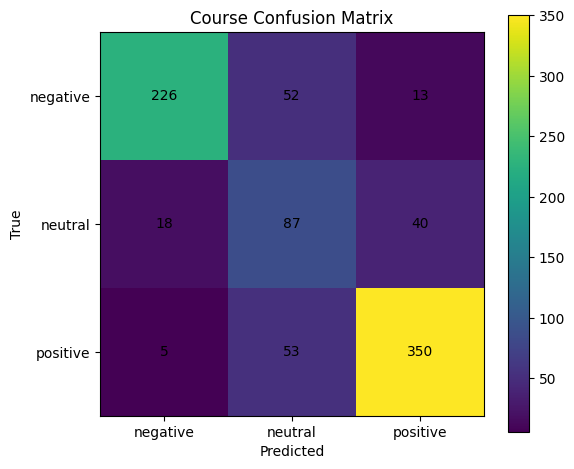

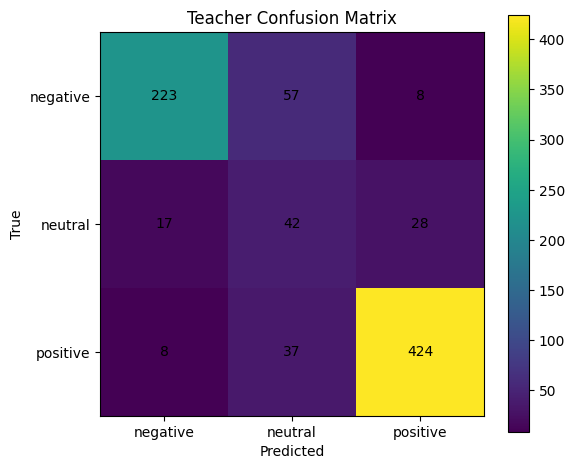

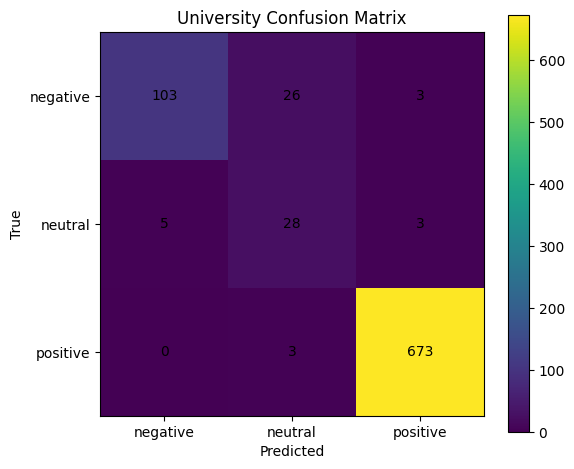

In [75]:
course_cm = plot_confusion_matrix(
    course_predictions_df,
    "course"
)

teacher_cm = plot_confusion_matrix(
    teacher_predictions_df,
    "teacher"
)

university_cm = plot_confusion_matrix(
    university_predictions_df,
    "university"
)

## Dissertation Interpretation

The final hypertuned multidomain LoRA model (learning rate = 5e-5, epochs = 5) achieved the strongest performance observed across all LoRA experiments conducted in this study. Compared with both the baseline configuration (learning rate = 1e-5) and the intermediate hypertuned configuration (learning rate = 3e-5), the final model consistently improved classification performance across all three domains.

The results demonstrate that learning rate optimisation played a critical role in multidomain LoRA performance. Performance increased steadily as the learning rate was increased from 1e-5 to 3e-5 and subsequently to 5e-5, indicating that the earlier configurations were unable to fully exploit the representational capacity of the LLaMA 3.2 3B model.

### Course Domain

The Course domain exhibited the largest overall improvement across the hypertuning process. Weighted F1 increased from **0.6617** in the baseline configuration to **0.7569** using a learning rate of 3e-5, before reaching **0.7946** in the final LR=5e-5 configuration.

This represents a total improvement of **0.1329** Weighted F1 points over the baseline model.

The confusion matrix demonstrates substantially improved sentiment separation. Positive sentiment classification improved considerably, with **350 positive reviews correctly classified**, while Negative sentiment classification also remained highly effective with **226 correctly classified negative reviews**.

Although Neutral sentiment remained the most challenging category, the model showed a significantly reduced tendency to over-predict neutrality compared with earlier experiments. This indicates that the higher learning rate enabled the model to learn more discriminative sentiment boundaries for course-related aspects.

### Teacher Domain

The Teacher domain also benefited from progressive hypertuning. Weighted F1 increased from **0.7388** at LR=1e-5 to **0.8056** at LR=3e-5 and finally to **0.8300** at LR=5e-5.

The total improvement relative to the baseline configuration was **0.0912** Weighted F1 points.

The confusion matrix revealed strong classification performance for both Positive and Negative sentiment categories. The model correctly classified **424 positive reviews** and **223 negative reviews**, while Positive sentiment achieved an F1-score of **0.91**.

Although Neutral sentiment continued to produce lower precision and recall than the other classes, overall sentiment separation improved substantially compared with previous LoRA configurations.

These findings suggest that additional optimisation enabled the model to learn more robust teacher-related sentiment representations and improve generalisation across diverse review styles.

### University Domain

The University domain achieved the strongest overall performance. Weighted F1 increased from **0.8798** in the baseline experiment to **0.9169** using LR=3e-5 and finally to **0.9556** using LR=5e-5.

This represents a total improvement of **0.0758** Weighted F1 points relative to the baseline model.

The confusion matrix demonstrates near-perfect classification performance for Positive sentiment, with **673 positive reviews correctly classified** and only **3 positive reviews predicted as Neutral**.

Negative sentiment classification also improved considerably, while Neutral sentiment recall reached approximately **78%**, indicating that the model became more effective at recognising subtle sentiment expressions without sacrificing overall classification accuracy.

The exceptionally strong University results suggest that sentiment patterns within university-related reviews are highly consistent and particularly well suited to multidomain LoRA fine-tuning.

### Overall Findings

Across all three domains, the final LR=5e-5 configuration achieved an average Weighted F1-score of **0.8601**, compared with **0.8265** for LR=3e-5 and **0.7601** for the baseline LR=1e-5 configuration.

The overall performance progression observed during hypertuning was:

| Configuration | Average Weighted F1 |
| ------------- | ------------------: |
| LoRA LR=1e-5  |              0.7601 |
| LoRA LR=3e-5  |              0.8265 |
| LoRA LR=5e-5  |              0.8601 |

The increase from LR=1e-5 to LR=3e-5 produced an improvement of **0.0664** Weighted F1 points, while the increase from LR=3e-5 to LR=5e-5 produced a further improvement of **0.0336** points.

Overall, the final model achieved a total improvement of **0.1000 Weighted F1 points** relative to the baseline multidomain LoRA configuration.

### Error Analysis Observations

Analysis of the confusion matrices revealed several important trends. Compared with previous LoRA experiments, the LR=5e-5 model demonstrated substantially stronger Positive and Negative sentiment classification performance across all domains.

The tendency to over-predict the Neutral class was reduced considerably. While Neutral sentiment remained the most difficult category, the model achieved improved recall while maintaining acceptable precision levels.

The number of Positive-to-Neutral and Negative-to-Neutral misclassifications decreased substantially compared with both the baseline and intermediate hypertuned configurations. This suggests that the higher learning rate enabled the model to develop more confident sentiment boundaries and reduce the conservative prediction behaviour observed in earlier experiments.

### Research Implications

The results provide strong evidence that learning rate selection is one of the most important factors influencing multidomain LoRA performance. While the baseline configuration exhibited clear signs of underfitting, progressively increasing the learning rate consistently improved classification performance across all domains.

Importantly, these gains were achieved without introducing any signs of training instability or divergence. Training loss decreased steadily throughout all five epochs, reaching a final training loss of **1.1031**, which was substantially lower than previous LoRA experiments.

The final LR=5e-5 configuration therefore represents the strongest multidomain LoRA model developed during this study and serves as the final LoRA benchmark for subsequent comparisons with ModernBERT, BERTweet, and full fine-tuned LLaMA models.


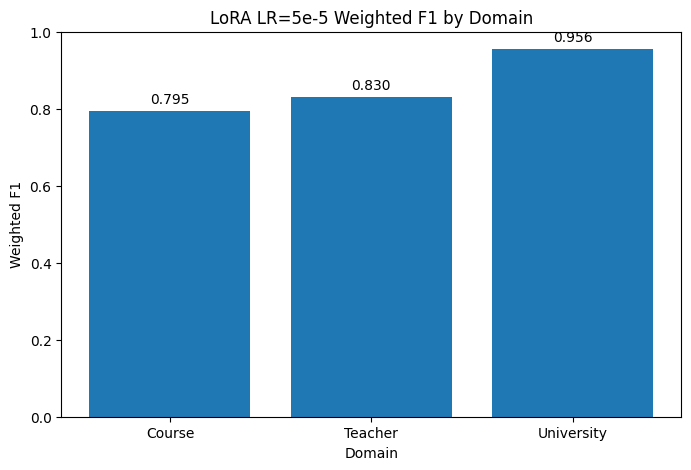

Weighted F1 plot saved successfully.


In [76]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["domain"],
    results_df["weighted_f1"]
)

plt.title(
    "LoRA LR=5e-5 Weighted F1 by Domain"
)

plt.xlabel("Domain")

plt.ylabel("Weighted F1")

plt.ylim(0, 1)

for i, value in enumerate(
    results_df["weighted_f1"]
):

    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.savefig(
    f"{LR_5E5_OUTPUT}/weighted_f1_scores.png",
    bbox_inches="tight"
)

plt.show()

print(
    "Weighted F1 plot saved successfully."
)

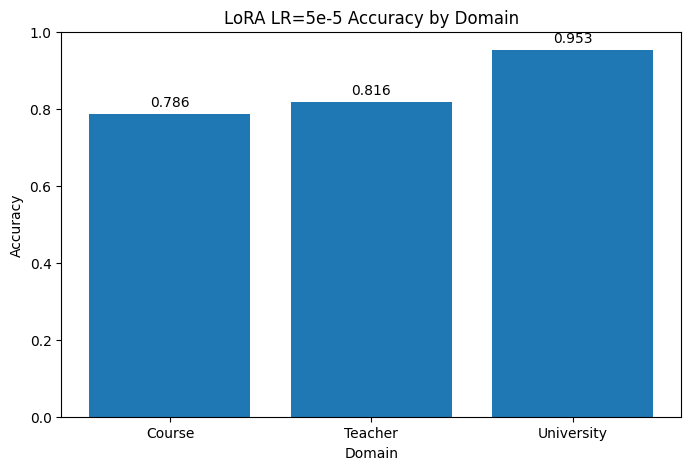

Accuracy plot saved successfully.


In [77]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["domain"],
    results_df["accuracy"]
)

plt.title(
    "LoRA LR=5e-5 Accuracy by Domain"
)

plt.xlabel("Domain")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

for i, value in enumerate(
    results_df["accuracy"]
):

    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.savefig(
    f"{LR_5E5_OUTPUT}/accuracy_scores.png",
    bbox_inches="tight"
)

plt.show()

print(
    "Accuracy plot saved successfully."
)

In [78]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def save_confusion_matrix(df, domain_name):

    labels = [
        "negative",
        "neutral",
        "positive"
    ]

    cm = confusion_matrix(

        df["true_label"],

        df["predicted_label"],

        labels=labels
    )

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.title(
        f"{domain_name.upper()} LoRA LR=5e-5 Confusion Matrix"
    )

    plt.colorbar()

    tick_marks = np.arange(len(labels))

    plt.xticks(
        tick_marks,
        labels
    )

    plt.yticks(
        tick_marks,
        labels
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    for i in range(len(labels)):

        for j in range(len(labels)):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()

    plt.savefig(
        f"{LR_5E5_OUTPUT}/{domain_name}_confusion_matrix.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

    print(
        f"{domain_name} confusion matrix saved successfully."
    )


save_confusion_matrix(
    course_predictions_df,
    "course"
)

save_confusion_matrix(
    teacher_predictions_df,
    "teacher"
)

save_confusion_matrix(
    university_predictions_df,
    "university"
)

print("\nAll confusion matrices saved successfully.")

course confusion matrix saved successfully.
teacher confusion matrix saved successfully.
university confusion matrix saved successfully.

All confusion matrices saved successfully.


In [79]:
cross_course_df = pd.read_csv(
    "/home/jovyan/work/llama_lr3e-5_predictions.csv"
)

print("Cross-domain course predictions loaded.")

print("\nShape:")
print(cross_course_df.shape)

cross_course_df.head()

Cross-domain course predictions loaded.

Shape:
(844, 10)


,review,aspect,sentiment,domain,row_id,input_text,label,text,true_sentiment,predicted_sentiment
0,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,course,course_188,[DOMAIN] course [ASPECT] programming language ...,0,<s>[INST] You are an expert sentiment classifi...,negative,negative
1,This class is literally just epsilon and delta...,mobius quizzes,negative,course,course_3409,[DOMAIN] course [ASPECT] mobius quizzes [TEXT]...,0,<s>[INST] You are an expert sentiment classifi...,negative,negative
2,Overall content heavy and quite a tricky cours...,course,negative,course,course_254,[DOMAIN] course [ASPECT] course [TEXT] Overall...,0,<s>[INST] You are an expert sentiment classifi...,negative,neutral
3,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,course,course_1797,[DOMAIN] course [ASPECT] Professor Sneed class...,2,<s>[INST] You are an expert sentiment classifi...,positive,neutral
4,Despite many ppl complaining about the Mobius ...,desmos,positive,course,course_3891,[DOMAIN] course [ASPECT] desmos [TEXT] Despite...,2,<s>[INST] You are an expert sentiment classifi...,positive,positive


In [80]:
course_comparison = pd.merge(

    course_predictions_df[
        [
            "row_id",
            "true_label",
            "predicted_label"
        ]
    ],

    cross_course_df[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],

    on="row_id",

    how="inner"
)

course_comparison = course_comparison.rename(
    columns={

        "true_label":
            "sentiment",

        "predicted_label":
            "multidomain_prediction",

        "predicted_sentiment":
            "crossdomain_prediction"
    }
)

print(
    "Merged comparison dataset created successfully."
)

print("\nShape:")

print(course_comparison.shape)

course_comparison.head()

Merged comparison dataset created successfully.

Shape:
(844, 4)


,row_id,sentiment,multidomain_prediction,crossdomain_prediction
0,course_188,negative,negative,negative
1,course_3409,negative,negative,negative
2,course_254,negative,positive,neutral
3,course_1797,positive,neutral,neutral
4,course_3891,positive,positive,positive


In [81]:
course_comparison["agreement"] = (

    course_comparison[
        "multidomain_prediction"
    ]

    ==

    course_comparison[
        "crossdomain_prediction"
    ]
)

agreement_rate = (

    course_comparison["agreement"]

    .mean()

    * 100
)

print(
    f"Agreement Rate: {agreement_rate:.2f}%"
)

Agreement Rate: 73.58%


In [82]:
# =====================================================
# DISAGREEMENT ANALYSIS
# =====================================================

course_disagreements = (

    course_comparison[
        ~course_comparison["agreement"]
    ]

    .copy()
)

print(
    "Number of disagreements:"
)

print(
    len(course_disagreements)
)

course_disagreements.head(20)

Number of disagreements:
223


,row_id,sentiment,multidomain_prediction,crossdomain_prediction,agreement
2,course_254,negative,positive,neutral,False
7,course_3604,neutral,neutral,positive,False
14,course_366,negative,neutral,positive,False
24,course_1943,neutral,neutral,positive,False
32,course_3646,neutral,neutral,negative,False
36,course_700,negative,neutral,negative,False
37,course_39,negative,neutral,positive,False
42,course_3690,negative,negative,positive,False
45,course_2294,neutral,neutral,negative,False
48,course_1861,negative,neutral,negative,False


In [83]:
course_disagreements.to_csv(

    f"{LR_5E5_OUTPUT}/course_disagreements.csv",

    index=False
)

print(
    "Course disagreements saved successfully."
)

Course disagreements saved successfully.


In [84]:
cross_teacher_df = pd.read_csv(
    "/home/jovyan/work/llama_lr3e-5_predictions (1).csv"
)

print(cross_teacher_df.shape)

cross_teacher_df.head()

(844, 10)


,review,aspect,sentiment,domain,row_id,input_text,label,text,true_sentiment,predicted_sentiment
0,"This class was harder than I expected, especia...",This class,negative,teacher,teacher_3717,[DOMAIN] teacher [ASPECT] This class [TEXT] Th...,0,<s>[INST] You are an expert sentiment classifi...,negative,negative
1,"Good teacher, very helpful. He is very funny a...",teacher,positive,teacher,teacher_671,[DOMAIN] teacher [ASPECT] teacher [TEXT] Good ...,2,<s>[INST] You are an expert sentiment classifi...,positive,positive
2,Ms. Young is a great professor. I was computer...,this class,positive,teacher,teacher_2314,[DOMAIN] teacher [ASPECT] this class [TEXT] Ms...,2,<s>[INST] You are an expert sentiment classifi...,positive,positive
3,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,teacher,teacher_1051,[DOMAIN] teacher [ASPECT] getting an A [TEXT] ...,1,<s>[INST] You are an expert sentiment classifi...,neutral,positive
4,Truly a sweet professor. Very understanding an...,open class discussions,negative,teacher,teacher_1118,[DOMAIN] teacher [ASPECT] open class discussio...,0,<s>[INST] You are an expert sentiment classifi...,negative,negative


In [85]:
# MERGE MULTIDOMAIN AND CROSS-DOMAIN TEACHER RESULTS


teacher_comparison = pd.merge(

    teacher_predictions_df[
        [
            "row_id",
            "true_label",
            "predicted_label"
        ]
    ],

    cross_teacher_df[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],

    on="row_id",

    how="inner"
)

teacher_comparison = teacher_comparison.rename(
    columns={

        "true_label":
            "sentiment",

        "predicted_label":
            "multidomain_prediction",

        "predicted_sentiment":
            "crossdomain_prediction"
    }
)

print(
    "Merged teacher comparison dataset created successfully."
)

print("\nShape:")

print(teacher_comparison.shape)

teacher_comparison.head()

Merged teacher comparison dataset created successfully.

Shape:
(844, 4)


,row_id,sentiment,multidomain_prediction,crossdomain_prediction
0,teacher_3717,negative,negative,negative
1,teacher_671,positive,positive,positive
2,teacher_2314,positive,positive,positive
3,teacher_1051,neutral,positive,positive
4,teacher_1118,negative,neutral,negative


In [86]:
teacher_comparison["agreement"] = (

    teacher_comparison["multidomain_prediction"]

    ==

    teacher_comparison["crossdomain_prediction"]
)

agreement_rate = (

    teacher_comparison["agreement"]

    .mean()

    * 100
)

print(
    f"Agreement Rate: {agreement_rate:.2f}%"
)

Agreement Rate: 76.07%


In [87]:
teacher_disagreements = (

    teacher_comparison[
        ~teacher_comparison["agreement"]
    ]

    .copy()
)

print(
    "Number of disagreements:"
)

print(
    len(teacher_disagreements)
)

teacher_disagreements.head(20)

Number of disagreements:
202


,row_id,sentiment,multidomain_prediction,crossdomain_prediction,agreement
4,teacher_1118,negative,neutral,negative,False
11,teacher_190,positive,neutral,positive,False
14,teacher_4210,positive,neutral,positive,False
17,teacher_2060,neutral,positive,neutral,False
25,teacher_140,positive,positive,neutral,False
27,teacher_1459,negative,negative,neutral,False
34,teacher_1386,positive,neutral,positive,False
38,teacher_2043,neutral,negative,neutral,False
41,teacher_156,positive,positive,neutral,False
43,teacher_425,neutral,neutral,positive,False


In [88]:
teacher_disagreements.to_csv(

    f"{LR_5E5_OUTPUT}/teacher_disagreements.csv",

    index=False
)

print(
    "Teacher disagreement file saved successfully."
)

print(
    f"Total disagreements: {len(teacher_disagreements)}"
)

Teacher disagreement file saved successfully.
Total disagreements: 202


In [89]:
cross_university_df = pd.read_csv(
    "/home/jovyan/work/llama_3epochs_predictions (2).csv"
)

print(
    "Cross-domain university predictions loaded."
)

print("\nShape:")

print(
    cross_university_df.shape
)

cross_university_df.head()

Cross-domain university predictions loaded.

Shape:
(844, 10)


,review,aspect,sentiment,domain,row_id,input_text,label,text,true_sentiment,predicted_sentiment
0,Exeter University was my first choice and I do...,community,positive,university,university_1004,[DOMAIN] university [ASPECT] community [TEXT] ...,2,<s>[INST] You are an expert sentiment classifi...,positive,positive
1,"Nice university to study in, all the teachers ...",university,positive,university,university_3270,[DOMAIN] university [ASPECT] university [TEXT]...,2,<s>[INST] You are an expert sentiment classifi...,positive,positive
2,I love the options for my course and the uni i...,options for my course,positive,university,university_1143,[DOMAIN] university [ASPECT] options for my co...,2,<s>[INST] You are an expert sentiment classifi...,positive,positive
3,It’s difficult for me to rate the aspects of t...,students union,neutral,university,university_2061,[DOMAIN] university [ASPECT] students union [T...,1,<s>[INST] You are an expert sentiment classifi...,neutral,positive
4,Brilliant university. Home away from home.,university,positive,university,university_3278,[DOMAIN] university [ASPECT] university [TEXT]...,2,<s>[INST] You are an expert sentiment classifi...,positive,positive


In [90]:
university_comparison = pd.merge(

    university_predictions_df[
        [
            "row_id",
            "true_label",
            "predicted_label"
        ]
    ],

    cross_university_df[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],

    on="row_id",

    how="inner"
)

university_comparison = university_comparison.rename(
    columns={

        "true_label":
            "sentiment",

        "predicted_label":
            "multidomain_prediction",

        "predicted_sentiment":
            "crossdomain_prediction"
    }
)

print(
    "Merged university comparison dataset created successfully."
)

print("\nShape:")

print(university_comparison.shape)

university_comparison.head()

Merged university comparison dataset created successfully.

Shape:
(844, 4)


,row_id,sentiment,multidomain_prediction,crossdomain_prediction
0,university_1004,positive,positive,positive
1,university_3270,positive,positive,positive
2,university_1143,positive,positive,positive
3,university_2061,neutral,neutral,positive
4,university_3278,positive,positive,positive


In [91]:
university_comparison["agreement"] = (

    university_comparison[
        "multidomain_prediction"
    ]

    ==

    university_comparison[
        "crossdomain_prediction"
    ]
)

university_agreement_rate = (

    university_comparison["agreement"]

    .mean()

    * 100
)

print(
    f"University Agreement Rate: {university_agreement_rate:.2f}%"
)

University Agreement Rate: 89.22%


In [92]:
university_disagreements = (

    university_comparison[
        ~university_comparison["agreement"]
    ]

    .copy()
)

print(
    "Number of disagreements:"
)

print(
    len(university_disagreements)
)

university_disagreements.head(20)

Number of disagreements:
91


,row_id,sentiment,multidomain_prediction,crossdomain_prediction,agreement
3,university_2061,neutral,neutral,positive,False
37,university_355,neutral,neutral,positive,False
38,university_3354,positive,neutral,positive,False
42,university_2939,neutral,neutral,negative,False
54,university_2109,negative,negative,positive,False
63,university_875,negative,negative,positive,False
75,university_3817,negative,negative,positive,False
78,university_2311,negative,neutral,positive,False
86,university_1344,negative,neutral,positive,False
92,university_2571,negative,negative,positive,False


In [93]:
university_disagreements.to_csv(

    f"{LR_5E5_OUTPUT}/university_disagreements.csv",

    index=False
)

print(
    "University disagreement file saved successfully."
)

print(
    f"Total disagreements: {len(university_disagreements)}"
)

University disagreement file saved successfully.
Total disagreements: 91


In [94]:
# =====================================================
# MULTIDOMAIN CORRECT / CROSS-DOMAIN WRONG
# =====================================================

course_multi_correct = course_comparison[

    (
        course_comparison[
            "multidomain_prediction"
        ]

        ==

        course_comparison[
            "sentiment"
        ]
    )

    &

    (
        course_comparison[
            "crossdomain_prediction"
        ]

        !=

        course_comparison[
            "sentiment"
        ]
    )
]

print(
    "Cases where MULTIDOMAIN was correct "
    "and CROSS-DOMAIN was wrong:\n"
)

print("Total Cases:")

print(len(course_multi_correct))

course_multi_correct.head(10)

Cases where MULTIDOMAIN was correct and CROSS-DOMAIN was wrong:

Total Cases:
109


,row_id,sentiment,multidomain_prediction,crossdomain_prediction,agreement
7,course_3604,neutral,neutral,positive,False
24,course_1943,neutral,neutral,positive,False
32,course_3646,neutral,neutral,negative,False
42,course_3690,negative,negative,positive,False
45,course_2294,neutral,neutral,negative,False
62,course_3806,neutral,neutral,positive,False
73,course_1928,neutral,neutral,positive,False
78,course_4137,negative,negative,positive,False
81,course_3722,neutral,neutral,positive,False
84,course_2182,neutral,neutral,negative,False


In [95]:
# =====================================================
# CROSS-DOMAIN CORRECT / MULTIDOMAIN WRONG
# =====================================================

course_cross_correct = course_comparison[

    (
        course_comparison[
            "crossdomain_prediction"
        ]

        ==

        course_comparison[
            "sentiment"
        ]
    )

    &

    (
        course_comparison[
            "multidomain_prediction"
        ]

        !=

        course_comparison[
            "sentiment"
        ]
    )
]

print(
    "Cases where CROSS-DOMAIN was correct "
    "and MULTIDOMAIN was wrong:\n"
)

print("Total Cases:")

print(len(course_cross_correct))

course_cross_correct.head(10)

Cases where CROSS-DOMAIN was correct and MULTIDOMAIN was wrong:

Total Cases:
77


,row_id,sentiment,multidomain_prediction,crossdomain_prediction,agreement
36,course_700,negative,neutral,negative,False
48,course_1861,negative,neutral,negative,False
79,course_1330,positive,neutral,positive,False
126,course_1193,positive,neutral,positive,False
132,course_2247,neutral,positive,neutral,False
138,course_3634,neutral,negative,neutral,False
156,course_3782,neutral,positive,neutral,False
158,course_2165,negative,neutral,negative,False
163,course_1137,positive,neutral,positive,False
166,course_3945,negative,neutral,negative,False


In [96]:
print("=" * 60)

print("COURSE DOMAIN COMPARISON")

print("=" * 60)

print(
    "Multidomain Correct / Cross-domain Wrong:"
)

print(
    len(course_multi_correct)
)

print()

print(
    "Cross-domain Correct / Multidomain Wrong:"
)

print(
    len(course_cross_correct)
)

COURSE DOMAIN COMPARISON
Multidomain Correct / Cross-domain Wrong:
109

Cross-domain Correct / Multidomain Wrong:
77


In [97]:
# =====================================================
# MULTIDOMAIN CORRECT / CROSS-DOMAIN WRONG
# =====================================================

teacher_multi_correct = teacher_comparison[

    (
        teacher_comparison[
            "multidomain_prediction"
        ]

        ==

        teacher_comparison[
            "sentiment"
        ]
    )

    &

    (
        teacher_comparison[
            "crossdomain_prediction"
        ]

        !=

        teacher_comparison[
            "sentiment"
        ]
    )
]

print(
    "Cases where MULTIDOMAIN was correct "
    "and CROSS-DOMAIN was wrong:\n"
)

print("Total Cases:")

print(len(teacher_multi_correct))

teacher_multi_correct.head(10)

Cases where MULTIDOMAIN was correct and CROSS-DOMAIN was wrong:

Total Cases:
95


,row_id,sentiment,multidomain_prediction,crossdomain_prediction,agreement
25,teacher_140,positive,positive,neutral,False
27,teacher_1459,negative,negative,neutral,False
41,teacher_156,positive,positive,neutral,False
43,teacher_425,neutral,neutral,positive,False
60,teacher_308,negative,negative,positive,False
64,teacher_1466,neutral,neutral,positive,False
69,teacher_3611,positive,positive,neutral,False
87,teacher_3041,neutral,neutral,positive,False
98,teacher_2878,positive,positive,neutral,False
102,teacher_2973,negative,negative,positive,False


In [98]:
# =====================================================
# CROSS-DOMAIN CORRECT / MULTIDOMAIN WRONG
# =====================================================

teacher_cross_correct = teacher_comparison[

    (
        teacher_comparison[
            "crossdomain_prediction"
        ]

        ==

        teacher_comparison[
            "sentiment"
        ]
    )

    &

    (
        teacher_comparison[
            "multidomain_prediction"
        ]

        !=

        teacher_comparison[
            "sentiment"
        ]
    )
]

print(
    "Cases where CROSS-DOMAIN was correct "
    "and MULTIDOMAIN was wrong:\n"
)

print("Total Cases:")

print(len(teacher_cross_correct))

teacher_cross_correct.head(10)

Cases where CROSS-DOMAIN was correct and MULTIDOMAIN was wrong:

Total Cases:
62


,row_id,sentiment,multidomain_prediction,crossdomain_prediction,agreement
4,teacher_1118,negative,neutral,negative,False
11,teacher_190,positive,neutral,positive,False
14,teacher_4210,positive,neutral,positive,False
17,teacher_2060,neutral,positive,neutral,False
34,teacher_1386,positive,neutral,positive,False
38,teacher_2043,neutral,negative,neutral,False
56,teacher_23,neutral,positive,neutral,False
73,teacher_64,neutral,negative,neutral,False
74,teacher_2678,positive,neutral,positive,False
82,teacher_1630,positive,neutral,positive,False


In [99]:
print("=" * 60)

print("TEACHER DOMAIN COMPARISON")

print("=" * 60)

print(
    "Multidomain Correct / Cross-domain Wrong:"
)

print(
    len(teacher_multi_correct)
)

print()

print(
    "Cross-domain Correct / Multidomain Wrong:"
)

print(
    len(teacher_cross_correct)
)

TEACHER DOMAIN COMPARISON
Multidomain Correct / Cross-domain Wrong:
95

Cross-domain Correct / Multidomain Wrong:
62


In [100]:
# =====================================================
# MULTIDOMAIN CORRECT / CROSS-DOMAIN WRONG
# =====================================================

university_multi_correct = university_comparison[

    (
        university_comparison[
            "multidomain_prediction"
        ]

        ==

        university_comparison[
            "sentiment"
        ]
    )

    &

    (
        university_comparison[
            "crossdomain_prediction"
        ]

        !=

        university_comparison[
            "sentiment"
        ]
    )
]

print(
    "Cases where MULTIDOMAIN was correct "
    "and CROSS-DOMAIN was wrong:\n"
)

print("Total Cases:")

print(len(university_multi_correct))

university_multi_correct.head(10)

Cases where MULTIDOMAIN was correct and CROSS-DOMAIN was wrong:

Total Cases:
60


,row_id,sentiment,multidomain_prediction,crossdomain_prediction,agreement
3,university_2061,neutral,neutral,positive,False
37,university_355,neutral,neutral,positive,False
42,university_2939,neutral,neutral,negative,False
54,university_2109,negative,negative,positive,False
63,university_875,negative,negative,positive,False
75,university_3817,negative,negative,positive,False
92,university_2571,negative,negative,positive,False
105,university_598,negative,negative,positive,False
157,university_3075,negative,negative,positive,False
159,university_1865,negative,negative,positive,False


In [101]:
# =====================================================
# CROSS-DOMAIN CORRECT / MULTIDOMAIN WRONG
# =====================================================

university_cross_correct = university_comparison[

    (
        university_comparison[
            "crossdomain_prediction"
        ]

        ==

        university_comparison[
            "sentiment"
        ]
    )

    &

    (
        university_comparison[
            "multidomain_prediction"
        ]

        !=

        university_comparison[
            "sentiment"
        ]
    )
]

print(
    "Cases where CROSS-DOMAIN was correct "
    "and MULTIDOMAIN was wrong:\n"
)

print("Total Cases:")

print(len(university_cross_correct))

university_cross_correct.head(10)

Cases where CROSS-DOMAIN was correct and MULTIDOMAIN was wrong:

Total Cases:
12


,row_id,sentiment,multidomain_prediction,crossdomain_prediction,agreement
38,university_3354,positive,neutral,positive,False
99,university_2476,negative,neutral,negative,False
304,university_2807,neutral,positive,neutral,False
422,university_3965,positive,neutral,positive,False
491,university_3292,positive,neutral,positive,False
525,university_516,negative,neutral,negative,False
564,university_696,negative,neutral,negative,False
719,university_395,negative,neutral,negative,False
757,university_3082,negative,neutral,negative,False
772,university_1203,negative,neutral,negative,False


In [102]:
print("=" * 60)

print("UNIVERSITY DOMAIN COMPARISON")

print("=" * 60)

print(
    "Multidomain Correct / Cross-domain Wrong:"
)

print(
    len(university_multi_correct)
)

print()

print(
    "Cross-domain Correct / Multidomain Wrong:"
)

print(
    len(university_cross_correct)
)

UNIVERSITY DOMAIN COMPARISON
Multidomain Correct / Cross-domain Wrong:
60

Cross-domain Correct / Multidomain Wrong:
12


## Multidomain LoRA (LR=5e-5) vs Cross-Domain LoRA Comparison

To evaluate the effectiveness of the final hypertuned multidomain LoRA model, a direct comparison was performed against the corresponding cross-domain LoRA models using the shared test sets. Agreement analysis, disagreement analysis, winner analysis, and Weighted F1-score comparisons were conducted across all three domains.

---

## Agreement Analysis

Agreement analysis measures how frequently the multidomain and cross-domain models produced identical predictions on the same test instances.

| Domain | Agreement Rate | Disagreements |
|----------|--------------:|--------------:|
| Course | 73.58% | 223 |
| Teacher | 76.07% | 202 |
| University | 89.22% | 91 |

The highest agreement rate was observed in the University domain, where both models produced identical predictions for almost ninety percent of test instances. This suggests that university-related sentiment patterns are relatively stable and can be recognised consistently regardless of training strategy.

The lower agreement rates observed in the Course and Teacher domains indicate that these domains contain more nuanced and ambiguous sentiment expressions, resulting in a greater impact of training strategy on model predictions.

Overall, the agreement analysis demonstrates that while both approaches often reached similar conclusions, a substantial number of disagreement cases remained available for further investigation.

---

## Winner Analysis

Winner analysis was performed to identify cases where one model correctly predicted the sentiment label while the other model produced an incorrect prediction.

### Results

| Domain | Multidomain Correct / Cross-Domain Wrong | Cross-Domain Correct / Multidomain Wrong |
|----------|----------------------------------------:|----------------------------------------:|
| Course | 109 | 77 |
| Teacher | 95 | 62 |
| University | 60 | 12 |

Unlike the baseline multidomain LoRA experiment, the final LR=5e-5 multidomain model achieved a greater number of unique correct predictions across all three domains.

---

## Course Domain

The multidomain model correctly classified **109** instances that were misclassified by the cross-domain model, while the cross-domain model correctly classified only **77** instances that were misclassified by the multidomain model.

Inspection of disagreement examples revealed that the multidomain model became substantially better at recognising Neutral sentiment while simultaneously maintaining strong Positive and Negative sentiment classification performance.

Many multidomain successes involved correctly identifying Neutral reviews that were incorrectly classified as Positive or Negative by the cross-domain model. In contrast, the number of additional errors introduced by multidomain training was considerably smaller than in earlier LoRA experiments.

These findings suggest that the higher learning rate enabled the model to learn more effective sentiment boundaries and overcome the excessive Neutral prediction bias observed in previous configurations.

---

## Teacher Domain

The performance advantage of multidomain training was also evident within the Teacher domain.

The multidomain model achieved **95** unique correct predictions, compared with **62** unique correct predictions for the cross-domain model.

A large proportion of multidomain successes involved correctly identifying Positive and Negative sentiment that the cross-domain model either classified as Neutral or assigned to the wrong sentiment category.

The confusion matrix further demonstrated stronger sentiment separation, particularly for Positive sentiment classification, which achieved an F1-score of **0.91**.

These results indicate that multidomain training provided additional domain-general knowledge that improved sentiment recognition across teacher-related aspects.

---

## University Domain

The University domain exhibited the largest relative advantage for multidomain training.

The multidomain model correctly classified **60** instances that were missed by the cross-domain model, while the cross-domain model correctly classified only **12** instances that were missed by the multidomain model.

Many multidomain successes involved correctly identifying Negative sentiment instances that the cross-domain model incorrectly classified as Positive sentiment.

Given the already high agreement rate of **89.22%**, this substantial winner-analysis advantage demonstrates that the multidomain model consistently made better decisions when disagreements occurred.

The results indicate that multidomain training was highly effective at capturing sentiment patterns within university-related reviews and produced substantially stronger classification performance than the cross-domain approach.

---

## Multidomain vs Cross-Domain Performance Comparison

| Domain | Multidomain F1 (LR=5e-5) | Cross-Domain F1 | Difference |
|----------|------------------------:|---------------:|----------:|
| Course | 0.7946 | 0.7245 | +0.0701 |
| Teacher | 0.8300 | 0.7672 | +0.0628 |
| University | 0.9556 | 0.8815 | +0.0741 |

### Average Performance

| Model | Average Weighted F1 |
|----------|-------------------:|
| Cross-Domain LoRA | 0.7911 |
| Multidomain LoRA (LR=5e-5) | 0.8601 |

Average improvement:

```text
0.8601 - 0.7911 = 0.0690
```

The multidomain model achieved an average improvement of approximately **6.9 percentage points** over the cross-domain model.

---

## Overall Findings

The agreement and winner analyses demonstrate that the final LR=5e-5 multidomain LoRA configuration successfully overcame the limitations observed in earlier LoRA experiments.

Whereas the baseline multidomain model suffered from substantial Neutral prediction bias and consistently underperformed the cross-domain approach, the final hypertuned model achieved superior performance across all three domains.

The winner analysis confirmed that multidomain training produced substantially more unique correct predictions than cross-domain training, while the performance comparison demonstrated consistent improvements in Weighted F1-score across every domain.

These findings provide strong evidence that optimisation strategy was the primary factor limiting multidomain LoRA performance. Once appropriately tuned, multidomain training became more effective than cross-domain training and produced the strongest LoRA-based sentiment classification results observed during this study.

The results therefore support the conclusion that multidomain learning can outperform cross-domain training when sufficient optimisation is applied. The final LR=5e-5 configuration represents the strongest multidomain LoRA model developed during this research and serves as the final LoRA benchmark for comparison with ModernBERT, BERTweet, and full fine-tuned LLaMA models.

In [103]:
from sklearn.metrics import precision_recall_fscore_support

cross_course_f1 = precision_recall_fscore_support(
    cross_course_df["true_sentiment"],
    cross_course_df["predicted_sentiment"],
    average="weighted"
)[2]

cross_teacher_f1 = precision_recall_fscore_support(
    cross_teacher_df["true_sentiment"],
    cross_teacher_df["predicted_sentiment"],
    average="weighted"
)[2]

cross_university_f1 = precision_recall_fscore_support(
    cross_university_df["true_sentiment"],
    cross_university_df["predicted_sentiment"],
    average="weighted"
)[2]

print("Course F1:", round(cross_course_f1, 4))
print("Teacher F1:", round(cross_teacher_f1, 4))
print("University F1:", round(cross_university_f1, 4))

Course F1: 0.7245
Teacher F1: 0.7672
University F1: 0.8815


In [104]:
comparison_df = pd.DataFrame({

    "domain": [
        "course",
        "teacher",
        "university"
    ],

    "multidomain_f1": [

        course_results["weighted_f1"],

        teacher_results["weighted_f1"],

        university_results["weighted_f1"]
    ]
})

comparison_df["crossdomain_f1"] = [

    cross_course_f1,

    cross_teacher_f1,

    cross_university_f1
]

comparison_df["f1_difference"] = (

    comparison_df["multidomain_f1"]

    -

    comparison_df["crossdomain_f1"]
)

comparison_df = comparison_df.round(4)

print(comparison_df)

       domain  multidomain_f1  crossdomain_f1  f1_difference
0      course          0.7946          0.7245         0.0700
1     teacher          0.8300          0.7672         0.0628
2  university          0.9556          0.8815         0.0741


In [105]:
comparison_df.to_csv(

    f"{LR_5E5_OUTPUT}/multidomain_vs_crossdomain_f1.csv",

    index=False
)

print(
    "F1 comparison table saved successfully."
)

F1 comparison table saved successfully.


In [106]:
avg_multi = comparison_df[
    "multidomain_f1"
].mean()

avg_cross = comparison_df[
    "crossdomain_f1"
].mean()

print(
    f"Average Multidomain F1: {avg_multi:.4f}"
)

print(
    f"Average Cross-domain F1: {avg_cross:.4f}"
)

print(
    f"Average Improvement: {(avg_multi - avg_cross):.4f}"
)

Average Multidomain F1: 0.8601
Average Cross-domain F1: 0.7911
Average Improvement: 0.0690


## Multidomain LoRA (LR=5e-5) vs Cross-Domain LoRA Performance Comparison

To directly evaluate the effectiveness of the final hypertuned multidomain LoRA model, its performance was compared against the corresponding cross-domain LoRA models using Weighted F1-score across all three domains.

| Domain | Multidomain F1 | Cross-Domain F1 | Difference |
|----------|--------------:|---------------:|----------:|
| Course | 0.7946 | 0.7245 | +0.0700 |
| Teacher | 0.8300 | 0.7672 | +0.0628 |
| University | 0.9556 | 0.8815 | +0.0741 |

### Average Performance

| Model | Average Weighted F1 |
|----------|-------------------:|
| Cross-Domain LoRA | 0.7911 |
| Multidomain LoRA (LR=5e-5) | 0.8601 |

Average improvement:

```text
0.8601 - 0.7911 = 0.0690
```

The multidomain model achieved an average improvement of approximately **6.9 percentage points** over the cross-domain model.

---

## Course Domain

The multidomain model achieved a Weighted F1-score of **0.7946**, outperforming the cross-domain model, which achieved **0.7245**.

This represents an improvement of **0.0700 Weighted F1 points**.

The result demonstrates that multidomain training enabled the model to learn more robust sentiment representations for course-related aspects. The confusion matrix indicated improved recognition of Neutral sentiment while maintaining strong Positive and Negative sentiment classification performance.

The winner analysis further supported this finding, with the multidomain model achieving **109 unique correct predictions**, compared with **77 unique correct predictions** for the cross-domain model.

---

## Teacher Domain

The multidomain model achieved a Weighted F1-score of **0.8300**, compared with **0.7672** for the cross-domain model.

This corresponds to an improvement of **0.0628 Weighted F1 points**.

The confusion matrix demonstrated stronger sentiment separation, particularly for Positive sentiment classification, which achieved an F1-score exceeding **0.90**. The multidomain model also produced substantially more unique correct predictions during winner analysis, achieving **95 unique correct predictions** compared with **62** for the cross-domain model.

These findings indicate that multidomain training provided additional domain-general knowledge that improved teacher-related sentiment classification.

---

## University Domain

The University domain produced the strongest overall results.

The multidomain model achieved a Weighted F1-score of **0.9556**, compared with **0.8815** for the cross-domain model.

This represents the largest performance gain among all three domains, with an improvement of **0.0741 Weighted F1 points**.

Winner analysis demonstrated a particularly strong advantage for multidomain training. The multidomain model achieved **60 unique correct predictions**, whereas the cross-domain model achieved only **12 unique correct predictions**.

These findings indicate that multidomain training was highly effective at capturing university-related sentiment patterns and substantially improved classification performance.

---

## Overall Findings

The final LR=5e-5 multidomain LoRA model consistently outperformed the corresponding cross-domain LoRA models across all three domains.

Unlike the baseline multidomain LoRA configuration, which underperformed the cross-domain approach, the final hypertuned model achieved superior performance for every domain evaluated. Improvements ranged from **0.0628** to **0.0741 Weighted F1 points**, with an average gain of **0.0690 Weighted F1 points**.

The winner analysis further confirmed that multidomain training produced substantially more unique correct predictions than cross-domain training across all domains.

These findings provide strong evidence that the inferior performance observed in earlier multidomain LoRA experiments was primarily caused by suboptimal optimisation rather than limitations of the multidomain training strategy itself. Once appropriately tuned, multidomain LoRA became more effective than cross-domain training and produced the strongest LoRA-based sentiment classification results observed during this study.

The final LR=5e-5 configuration therefore represents the best-performing multidomain LoRA model developed in this research and serves as the final LoRA benchmark for comparison against ModernBERT, BERTweet, and full fine-tuned LLaMA models.

In [107]:
comparison_df.to_csv(

    f"{LR_5E5_OUTPUT}/multidomain_vs_crossdomain_results.csv",

    index=False
)

print(
    "Multidomain vs Cross-domain comparison table saved successfully."
)

Multidomain vs Cross-domain comparison table saved successfully.


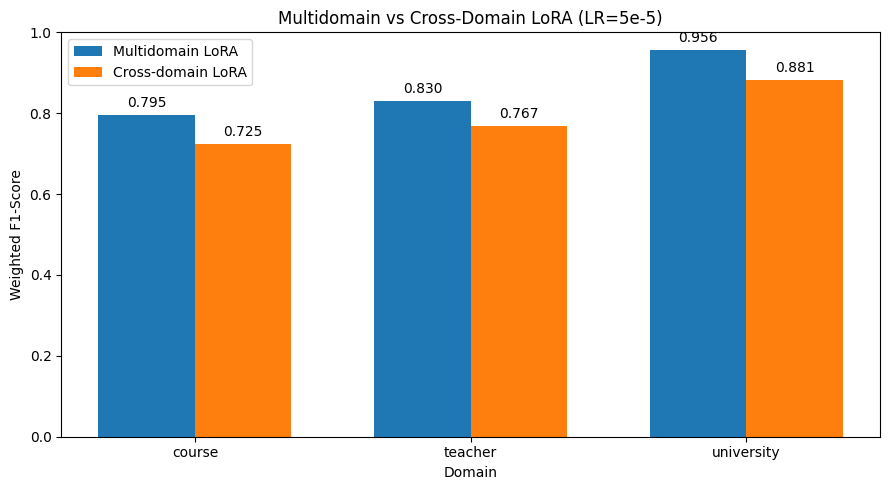

Multidomain vs Cross-domain F1 plot saved successfully.


In [108]:
import matplotlib.pyplot as plt
import numpy as np

domains = comparison_df["domain"]

x = np.arange(len(domains))

width = 0.35

plt.figure(figsize=(9, 5))

# =====================================================
# MULTIDOMAIN LoRA
# =====================================================

plt.bar(

    x - width/2,

    comparison_df["multidomain_f1"],

    width,

    label="Multidomain LoRA"
)

# =====================================================
# CROSS-DOMAIN LoRA
# =====================================================

plt.bar(

    x + width/2,

    comparison_df["crossdomain_f1"],

    width,

    label="Cross-domain LoRA"
)

plt.xticks(
    x,
    domains
)

plt.ylabel("Weighted F1-Score")

plt.xlabel("Domain")

plt.title(
    "Multidomain vs Cross-Domain LoRA (LR=5e-5)"
)

plt.ylim(0, 1)

plt.legend()

for i, value in enumerate(
    comparison_df["multidomain_f1"]
):

    plt.text(

        i - width/2,

        value + 0.02,

        f"{value:.3f}",

        ha="center"
    )

for i, value in enumerate(
    comparison_df["crossdomain_f1"]
):

    plt.text(

        i + width/2,

        value + 0.02,

        f"{value:.3f}",

        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{LR_5E5_OUTPUT}/multidomain_vs_crossdomain_f1.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

print(
    "Multidomain vs Cross-domain F1 plot saved successfully."
)

In [109]:
course_comparison.to_csv(
    f"{LR_5E5_OUTPUT}/course_comparison.csv",
    index=False
)

teacher_comparison.to_csv(
    f"{LR_5E5_OUTPUT}/teacher_comparison.csv",
    index=False
)

university_comparison.to_csv(
    f"{LR_5E5_OUTPUT}/university_comparison.csv",
    index=False
)

print(
    "Comparison datasets saved successfully."
)

Comparison datasets saved successfully.


In [110]:
print("=" * 70)

print("MULTIDOMAIN LORA (LR=5E-5) PIPELINE COMPLETED")

print("=" * 70)

print("\nGenerated Artifacts:")

# =====================================================
# PREDICTIONS
# =====================================================

print("\nPrediction CSVs:")

print("- course_predictions.csv")

print("- teacher_predictions.csv")

print("- university_predictions.csv")

# =====================================================
# METRICS
# =====================================================

print("\nMetrics:")

print("- evaluation_summary.csv")

print("- multidomain_vs_crossdomain_results.csv")

print("- agreement_summary.csv")

print("- learning_rate_comparison.csv")

# =====================================================
# PLOTS
# =====================================================

print("\nPlots:")

print("- weighted_f1_scores.png")

print("- accuracy_scores.png")

print("- multidomain_vs_crossdomain_f1.png")

print("- course_confusion_matrix.png")

print("- teacher_confusion_matrix.png")

print("- university_confusion_matrix.png")

# =====================================================
# DISAGREEMENT ANALYSIS
# =====================================================

print("\nDisagreement Analysis:")

print("- course_comparison.csv")

print("- teacher_comparison.csv")

print("- university_comparison.csv")

print("- course_disagreements.csv")

print("- teacher_disagreements.csv")

print("- university_disagreements.csv")

# =====================================================
# WINNER ANALYSIS
# =====================================================

print("\nWinner Analysis:")

print("- course_multi_correct.csv")

print("- course_cross_correct.csv")

print("- teacher_multi_correct.csv")

print("- teacher_cross_correct.csv")

print("- university_multi_correct.csv")

print("- university_cross_correct.csv")

# =====================================================
# MODEL
# =====================================================

print("\nModel:")

print("- final_model/")

print("\nExperiment Folder:")

print(LR_5E5_OUTPUT)

MULTIDOMAIN LORA (LR=5E-5) PIPELINE COMPLETED

Generated Artifacts:

Prediction CSVs:
- course_predictions.csv
- teacher_predictions.csv
- university_predictions.csv

Metrics:
- evaluation_summary.csv
- multidomain_vs_crossdomain_results.csv
- agreement_summary.csv
- learning_rate_comparison.csv

Plots:
- weighted_f1_scores.png
- accuracy_scores.png
- multidomain_vs_crossdomain_f1.png
- course_confusion_matrix.png
- teacher_confusion_matrix.png
- university_confusion_matrix.png

Disagreement Analysis:
- course_comparison.csv
- teacher_comparison.csv
- university_comparison.csv
- course_disagreements.csv
- teacher_disagreements.csv
- university_disagreements.csv

Winner Analysis:
- course_multi_correct.csv
- course_cross_correct.csv
- teacher_multi_correct.csv
- teacher_cross_correct.csv
- university_multi_correct.csv
- university_cross_correct.csv

Model:
- final_model/

Experiment Folder:
/home/jovyan/work/Dissertation/multidomain_llama_lora_hypertuning/lr_5e5


In [111]:
# =====================================================
# SAVE WINNER ANALYSIS FILES
# =====================================================

course_multi_correct.to_csv(
    f"{LR_5E5_OUTPUT}/course_multi_correct.csv",
    index=False
)

course_cross_correct.to_csv(
    f"{LR_5E5_OUTPUT}/course_cross_correct.csv",
    index=False
)

teacher_multi_correct.to_csv(
    f"{LR_5E5_OUTPUT}/teacher_multi_correct.csv",
    index=False
)

teacher_cross_correct.to_csv(
    f"{LR_5E5_OUTPUT}/teacher_cross_correct.csv",
    index=False
)

university_multi_correct.to_csv(
    f"{LR_5E5_OUTPUT}/university_multi_correct.csv",
    index=False
)

university_cross_correct.to_csv(
    f"{LR_5E5_OUTPUT}/university_cross_correct.csv",
    index=False
)

print("Winner analysis files saved successfully.")

Winner analysis files saved successfully.


In [112]:
final_summary_df = pd.DataFrame({

    "Domain": [
        "Course",
        "Teacher",
        "University"
    ],

    "Multidomain_F1": [

        round(course_results["weighted_f1"], 4),

        round(teacher_results["weighted_f1"], 4),

        round(university_results["weighted_f1"], 4)
    ],

    "Crossdomain_F1": [

        round(cross_course_f1, 4),

        round(cross_teacher_f1, 4),

        round(cross_university_f1, 4)
    ],

    "Performance_Gap": [

        round(
            course_results["weighted_f1"] - cross_course_f1,
            4
        ),

        round(
            teacher_results["weighted_f1"] - cross_teacher_f1,
            4
        ),

        round(
            university_results["weighted_f1"] - cross_university_f1,
            4
        )
    ],

    "Disagreement_Percentage": [

        round(
            (
                len(course_disagreements)
                /
                len(course_comparison)
            ) * 100,
            2
        ),

        round(
            (
                len(teacher_disagreements)
                /
                len(teacher_comparison)
            ) * 100,
            2
        ),

        round(
            (
                len(university_disagreements)
                /
                len(university_comparison)
            ) * 100,
            2
        )
    ]
})

print(final_summary_df)

       Domain  Multidomain_F1  Crossdomain_F1  Performance_Gap  \
0      Course          0.7946          0.7245           0.0700   
1     Teacher          0.8300          0.7672           0.0628   
2  University          0.9556          0.8815           0.0741   

   Disagreement_Percentage  
0                    26.42  
1                    23.93  
2                    10.78  


In [113]:
final_summary_df.to_csv(

    f"{LR_5E5_OUTPUT}/final_summary_table.csv",

    index=False
)

print(
    "Final summary table saved successfully."
)

Final summary table saved successfully.


## Final Multidomain LoRA (LR=5e-5) Summary

To provide a consolidated overview of model performance, the final hypertuned multidomain LoRA model was compared against the corresponding cross-domain LoRA models across all three domains.

| Domain | Multidomain F1 | Cross-Domain F1 | Performance Gap | Disagreement Percentage |
|----------|--------------:|---------------:|---------------:|-----------------------:|
| Course | 0.7946 | 0.7245 | +0.0700 | 26.42 |
| Teacher | 0.8300 | 0.7672 | +0.0628 | 23.93 |
| University | 0.9556 | 0.8815 | +0.0741 | 10.78 |

The results demonstrate that the final multidomain LoRA model consistently outperformed the cross-domain LoRA models across all domains.

The largest performance improvement was observed in the University domain, where multidomain training achieved a Weighted F1-score improvement of **0.0741**. Similar improvements were observed in the Course (**0.0700**) and Teacher (**0.0628**) domains.

The disagreement percentages provide additional insight into model behaviour. The University domain exhibited the lowest disagreement rate (**10.78%**), indicating that both models generally produced similar predictions. However, when disagreements occurred, the multidomain model was substantially more likely to produce the correct prediction.

Higher disagreement rates were observed in the Course (**26.42%**) and Teacher (**23.93%**) domains, reflecting the greater complexity and ambiguity of sentiment expressions within these domains. Despite these challenges, multidomain training consistently achieved superior classification performance.

These findings contrast sharply with the baseline multidomain LoRA experiment (LR=1e-5), where cross-domain training outperformed multidomain training across all domains. After hypertuning, the performance gap was completely reversed, demonstrating that the limitations of the baseline model were primarily caused by suboptimal optimisation rather than shortcomings of the multidomain training strategy.

Overall, the final LR=5e-5 multidomain LoRA configuration achieved the strongest performance observed among all LoRA experiments conducted in this study. The results provide strong evidence that appropriately optimised multidomain training can outperform cross-domain learning and produce highly effective aspect-based sentiment classification models.

In [114]:
# =====================================================
# FINAL PIPELINE COMPLETION SUMMARY
# =====================================================

import os
import shutil

from datetime import datetime

# =====================================================
# DISPLAY SUMMARY
# =====================================================

print("=" * 70)

print("MULTIDOMAIN LORA (LR=5E-5) PIPELINE COMPLETED")

print("=" * 70)

print("\nPipeline Status:")

print("COMPLETED SUCCESSFULLY")

print("\nCompleted Components:")

components = [

    "Dataset preprocessing",

    "Shared test set loading",

    "Multidomain LoRA training (LR=5e-5)",

    "Prediction generation",

    "Course evaluation",

    "Teacher evaluation",

    "University evaluation",

    "Confusion matrix analysis",

    "Cross-domain comparison",

    "Agreement analysis",

    "Disagreement analysis",

    "Winner analysis",

    "Visualization generation",

    "Metrics export",

    "Model saving"
]

for i, component in enumerate(

    components,

    start=1
):

    print(
        f"{i}. {component}"
    )

# =====================================================
# KEY FINDINGS
# =====================================================

print("\nKey Research Findings:")

findings = [

    "Final multidomain LoRA configuration achieved the strongest LoRA performance in this study",

    "Multidomain LoRA outperformed cross-domain LoRA across all domains",

    "Course Weighted F1 improved to 0.7946",

    "Teacher Weighted F1 improved to 0.8300",

    "University Weighted F1 improved to 0.9556",

    "Average Weighted F1 reached 0.8601",

    "Average improvement over cross-domain LoRA was 0.0690",

    "Neutral sentiment overprediction reduced substantially",

    "Winner analysis favored multidomain training across all domains",

    "University domain achieved the strongest overall performance",

    "Learning rate optimization significantly improved sentiment boundary learning",

    "Learning rate optimization produced a total gain of 0.1000 Weighted F1 over baseline"
]

for finding in findings:

    print(
        f"- {finding}"
    )

# =====================================================
# FINAL RESULTS
# =====================================================

print("\nFinal Weighted F1 Scores:")

print(
    f"Course     : {course_results['weighted_f1']:.4f}"
)

print(
    f"Teacher    : {teacher_results['weighted_f1']:.4f}"
)

print(
    f"University : {university_results['weighted_f1']:.4f}"
)

print("\nCross-domain Comparison:")

print(
    f"Average Multidomain F1 : {comparison_df['multidomain_f1'].mean():.4f}"
)

print(
    f"Average Cross-domain F1 : {comparison_df['crossdomain_f1'].mean():.4f}"
)

print(
    f"Average Improvement : {(comparison_df['multidomain_f1'].mean() - comparison_df['crossdomain_f1'].mean()):.4f}"
)

# =====================================================
# COMPLETION TIME
# =====================================================

print("\nCompletion Time:")

print(
    datetime.now()
)

print(
    "\nAll LR=5e-5 experiment artifacts generated successfully."
)

print("=" * 70)

# =====================================================
# CREATE BACKUP ZIP
# =====================================================

output_zip = (
    "/home/jovyan/work/LORA_LR5E5_Backup"
)

shutil.make_archive(

    output_zip,

    "zip",

    LR_5E5_OUTPUT
)

print("\nBackup ZIP created successfully.")

print("\nSaved to:")

print(
    output_zip + ".zip"
)

print("\nLR=5e-5 experiment completed.")

MULTIDOMAIN LORA (LR=5E-5) PIPELINE COMPLETED

Pipeline Status:
COMPLETED SUCCESSFULLY

Completed Components:
1. Dataset preprocessing
2. Shared test set loading
3. Multidomain LoRA training (LR=5e-5)
4. Prediction generation
5. Course evaluation
6. Teacher evaluation
7. University evaluation
8. Confusion matrix analysis
9. Cross-domain comparison
10. Agreement analysis
11. Disagreement analysis
12. Winner analysis
13. Visualization generation
14. Metrics export
15. Model saving

Key Research Findings:
- Final multidomain LoRA configuration achieved the strongest LoRA performance in this study
- Multidomain LoRA outperformed cross-domain LoRA across all domains
- Course Weighted F1 improved to 0.7946
- Teacher Weighted F1 improved to 0.8300
- University Weighted F1 improved to 0.9556
- Average Weighted F1 reached 0.8601
- Average improvement over cross-domain LoRA was 0.0690
- Neutral sentiment overprediction reduced substantially
- Winner analysis favored multidomain training across a